# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Frank de Kogel| 6582737 |
| Student naam 3| Student Studienummer 3 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Frank', 'Kimi']

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 16:30 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:15 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [51]
Bij onze kalibratieopstelling meten we enkel de afstand heen (er is geen afstand terug)
<img src="kalibratie_echo.jpeg" width="400">

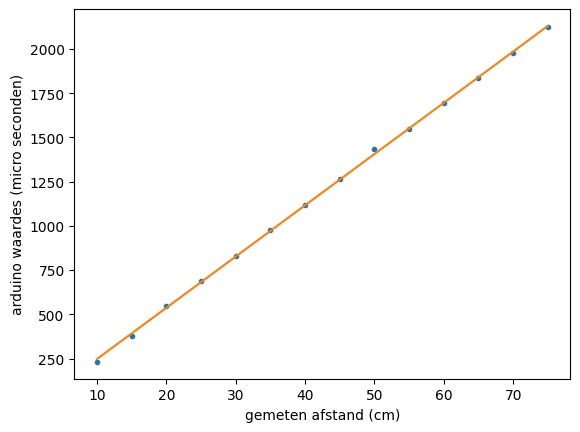

[ 28.97450549 -42.48791209]


In [3]:
# verwerk hier jullie kalibratiemetingen

fysiek = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]) # afstanden in centimeters (voorkant vericale platen)
arduino = np.array([231, 378, 549, 687, 830, 975, 1119, 1266, 1433, 1548, 1693, 1837, 1977, 2122]) # Meettijden in microseconden

def fit(x, a, b):
    return a*x + b

vals, covs = curve_fit(fit, fysiek, arduino)
xtest = np.linspace(np.min(fysiek), np.max(fysiek), 500)
ytest = fit(xtest, *vals)

plt.figure()
plt.plot(fysiek, arduino, '.', label = 'meetdata')
plt.plot(xtest, ytest, label = 'fit')
plt.xlabel('gemeten afstand (cm)')
plt.ylabel('arduino waardes (micro seconden)')
plt.show()

print(vals)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.1
2  40   0  30   0  39.9
3  30   0  20   0  40.3


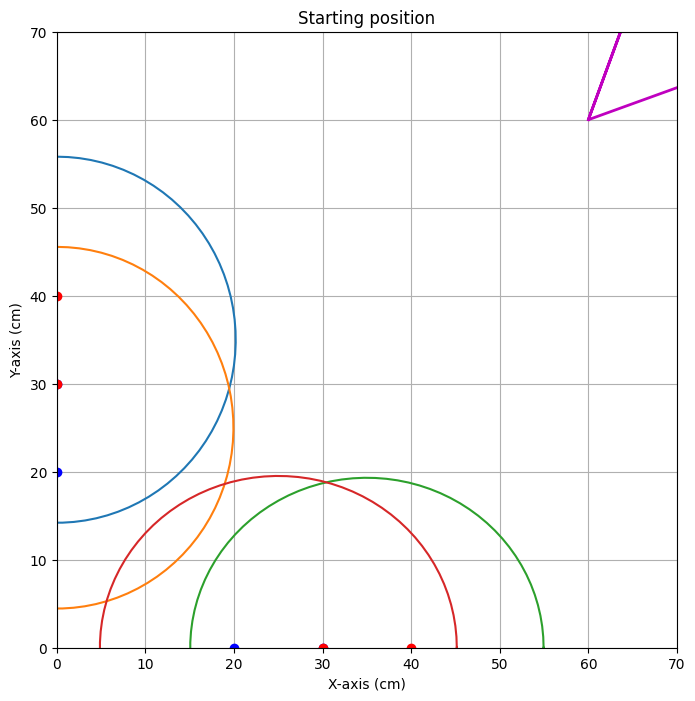


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.230


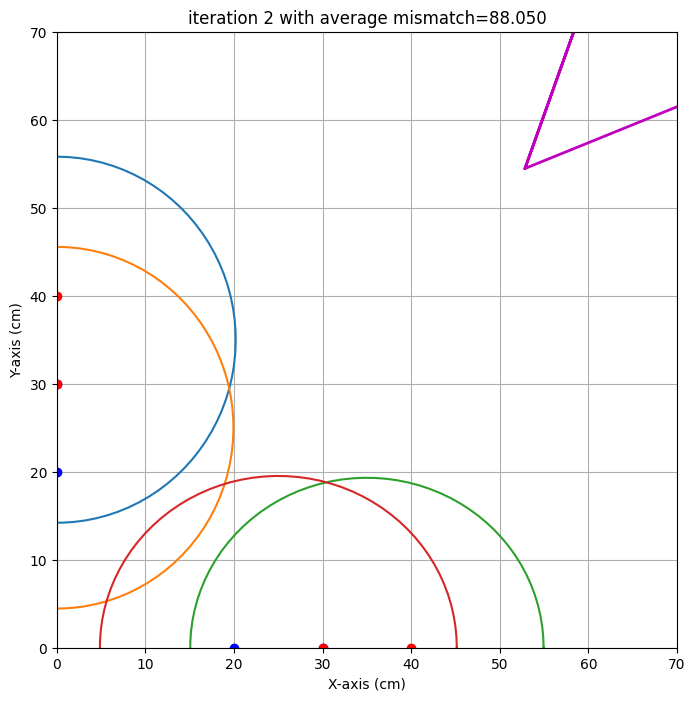

end iteration 2 with average mismatch=88.050


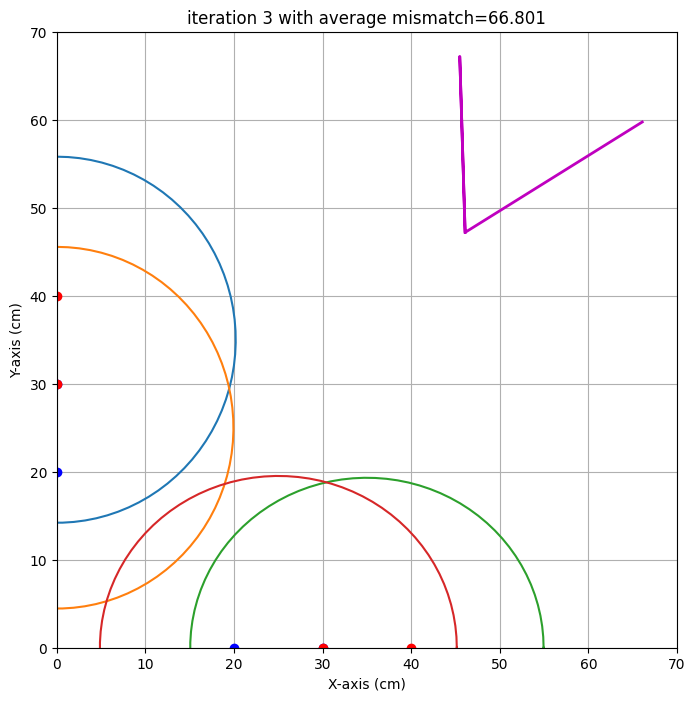

end iteration 3 with average mismatch=66.801


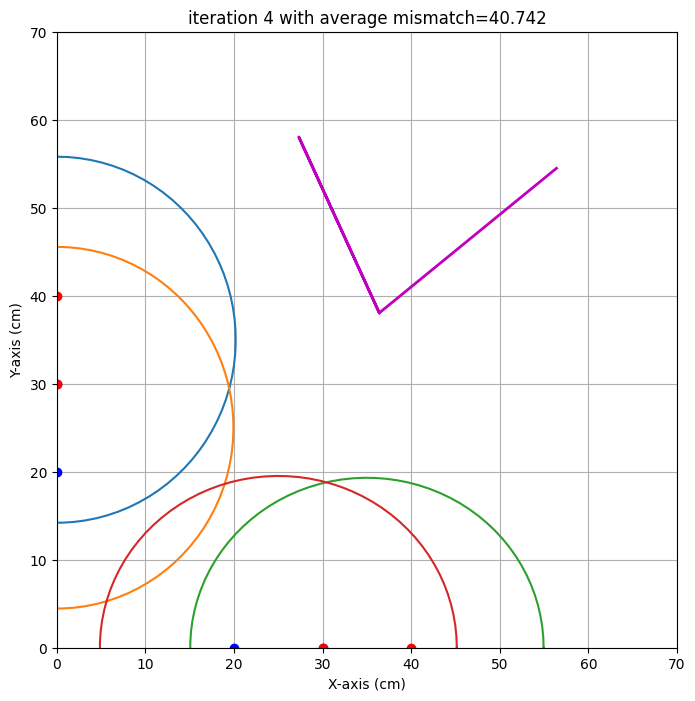

end iteration 4 with average mismatch=40.742


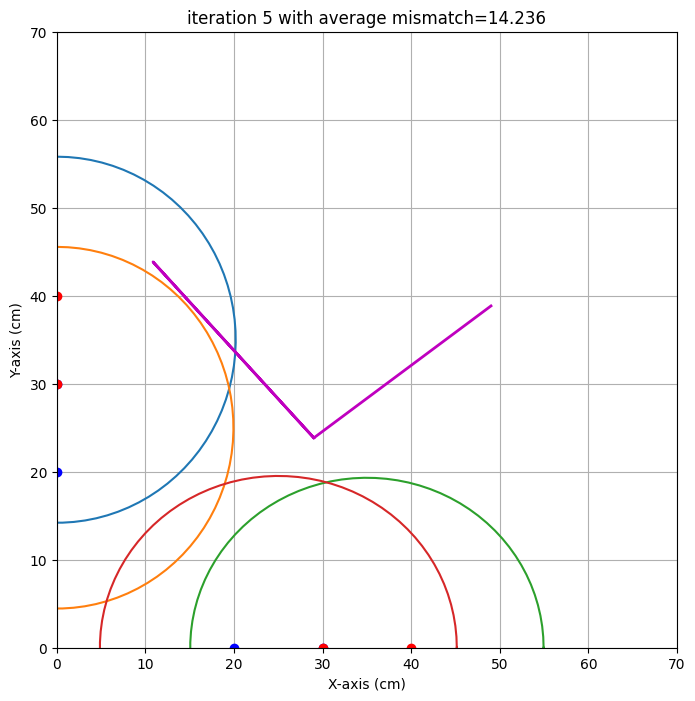

end iteration 5 with average mismatch=14.236


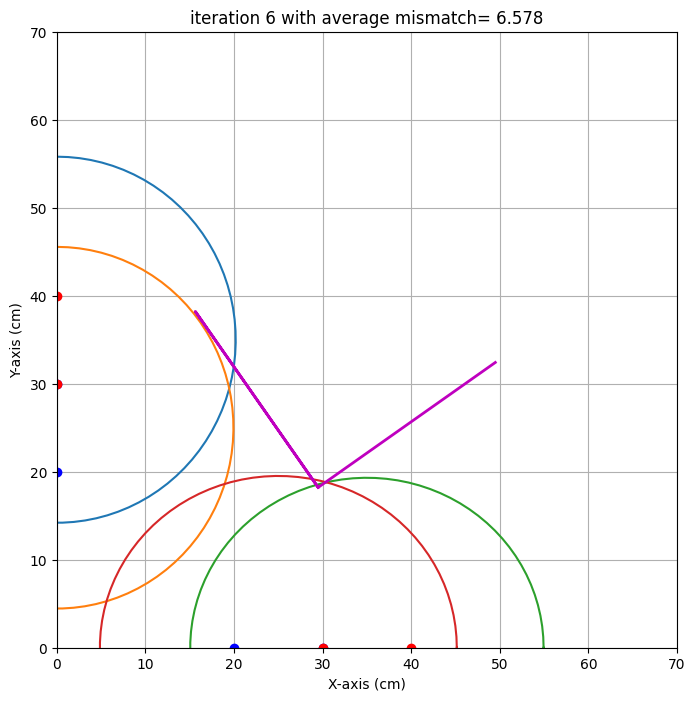

end iteration 6 with average mismatch= 6.578
end iteration 7 with average mismatch= 6.505
end iteration 8 with average mismatch= 6.489
end iteration 9 with average mismatch= 5.926


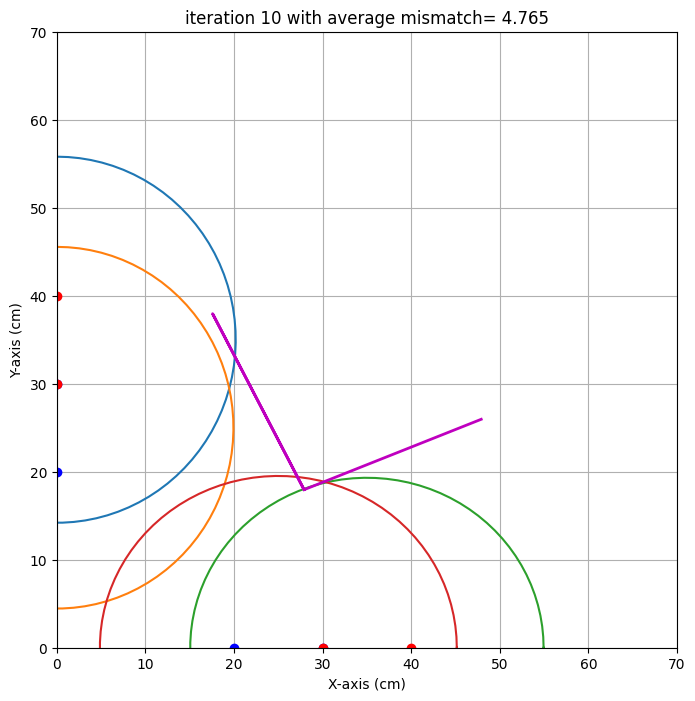

end iteration 10 with average mismatch= 4.765


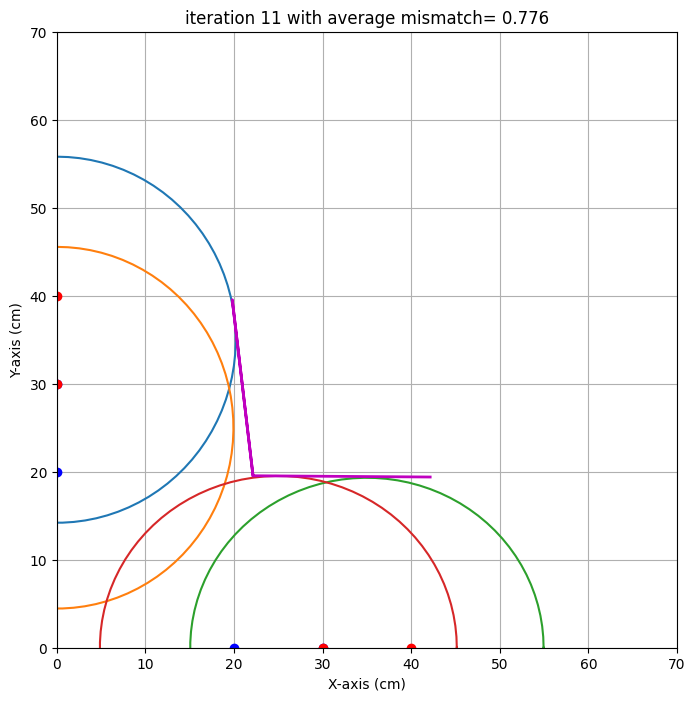

end iteration 11 with average mismatch= 0.776
end iteration 12 with average mismatch= 0.776
end iteration 13 with average mismatch= 0.776
end iteration 14 with average mismatch= 0.776
end iteration 15 with average mismatch= 0.776
end iteration 16 with average mismatch= 0.776
end iteration 17 with average mismatch= 0.738


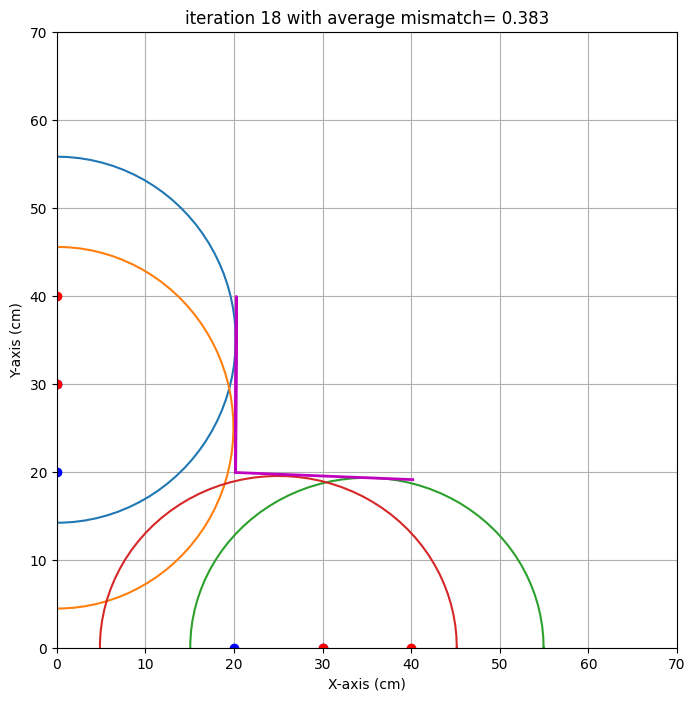

end iteration 18 with average mismatch= 0.383
end iteration 19 with average mismatch= 0.377
end iteration 20 with average mismatch= 0.373
end iteration 21 with average mismatch= 0.372
end iteration 22 with average mismatch= 0.372
end iteration 23 with average mismatch= 0.362


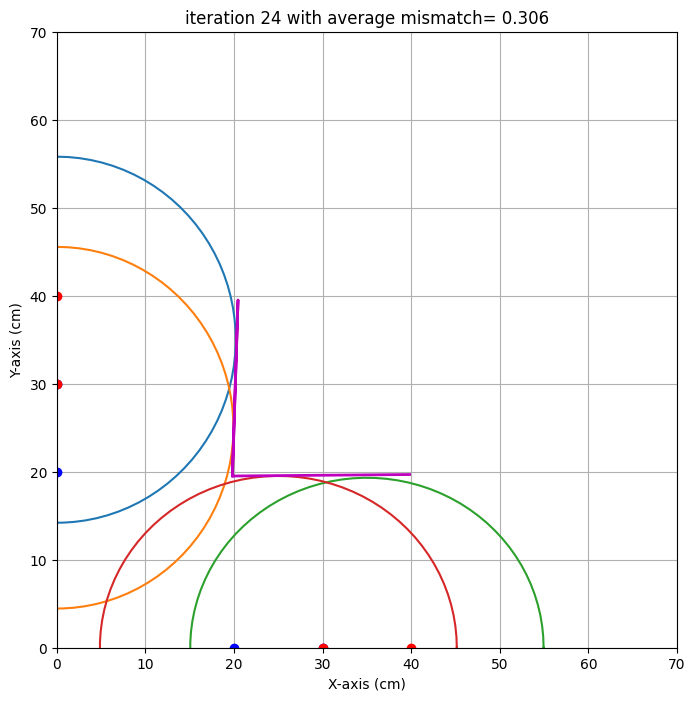

end iteration 24 with average mismatch= 0.306


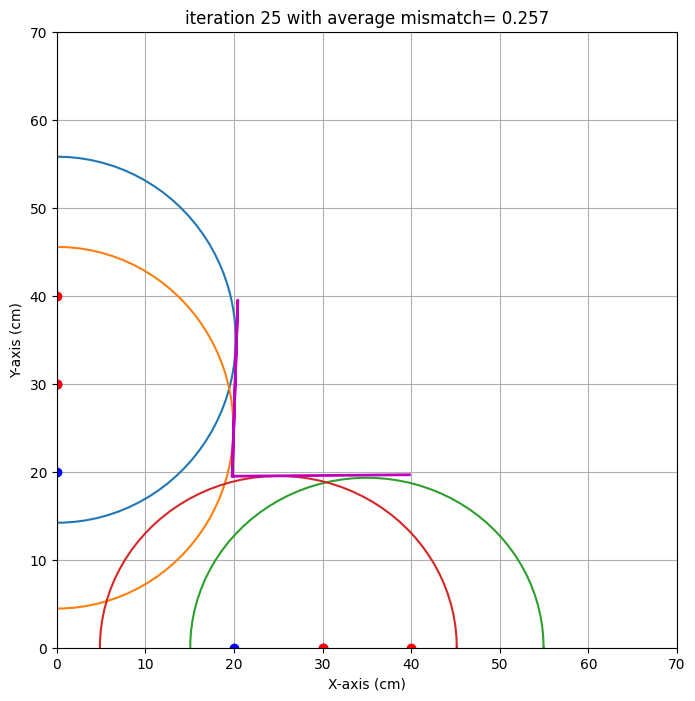

end iteration 25 with average mismatch= 0.257
end iteration 26 with average mismatch= 0.233
end iteration 27 with average mismatch= 0.226
end iteration 28 with average mismatch= 0.223
end iteration 29 with average mismatch= 0.222
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.222
###############################################################################
end of iteration  30
Best alpha=   0.46 with uncertainty=   0.24
Best beta =   1.79 with uncertainty=   1.68
Best x0   =  19.77 with uncertainty=   0.02
Best y0   =  19.47 with uncertainty=   0.11
###############################################################################


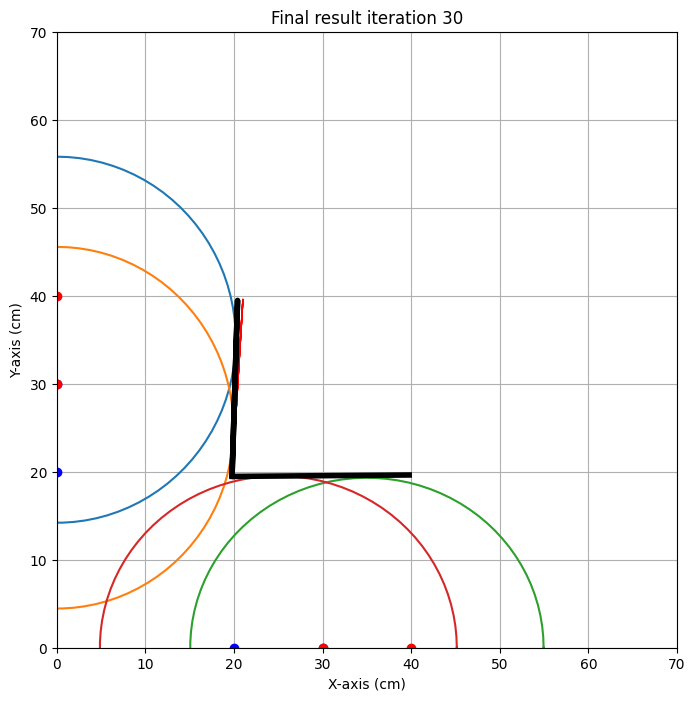

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.1],
    #[0,10,0,20,180], deze meting was onrealistisch, dus uitgecomment
    [40,0,30,0,39.9],
    [30,0,20,0,40.3],
    #[10,0,20,0,199.98], deze meting ongeldig voor dezelfde reden, hij pakt de hoek
    #[10,0,0,10,187.63], deze meting ongeldig, nam de hoek mee    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.0 cm 
y0: 19.5 cm met een standaardafwijking van 0.1 cm 
alpha: 0.5 graden met een standaardafwijking van 0.2 graad 
beta: 1.8 graden met een standaardafwijking van 1.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Kimi]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie0Kimi.jpeg" width="400">

#### algoritme [Frank]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Iteratie0Frank.jpeg" width="400">

geen derde student

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35,
           'y0':32,#zelf aanvullen,
           'alpha' :30, #zelf aanvullen,
           'beta' : 0,#zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frank' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,69.8],
    [45,0,20,0,66.8],
    #[0,45,0,70,x]
    [0,45,0,20,63.3],
    [0,60,0,20,71.6],
    [70,0,30,0,71.4]
    ]),
    'Kimi' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,x],
    [50,0,60,0,84.2],
    [0,30,0,40,71.4],
    #[0,35,0,45,x],
    #[0,40,0,50,x],
    [0,35,0,45,67.9],
    [0,40,0,50,65.5]
    ])
      }

## Opdracht 7: Evaluatie.

Frank
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  70   0  69.8
1  45   0  20   0  66.8
2   0  45   0  20  63.3
3   0  60   0  20  71.6
4  70   0  30   0  71.4


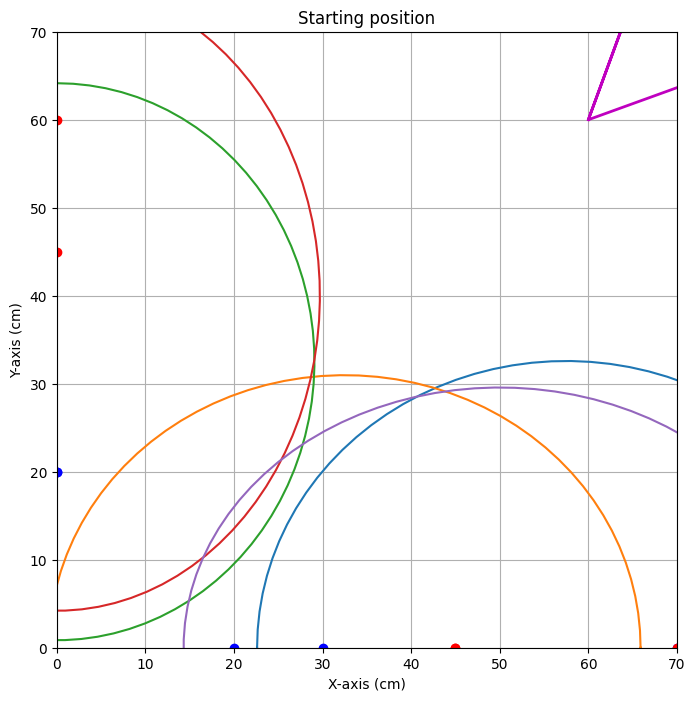


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.630


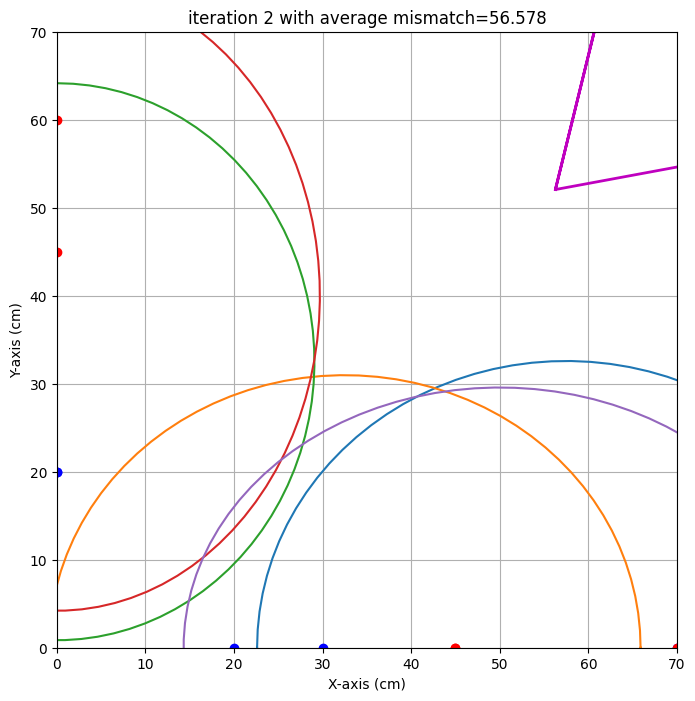

end iteration 2 with average mismatch=56.578


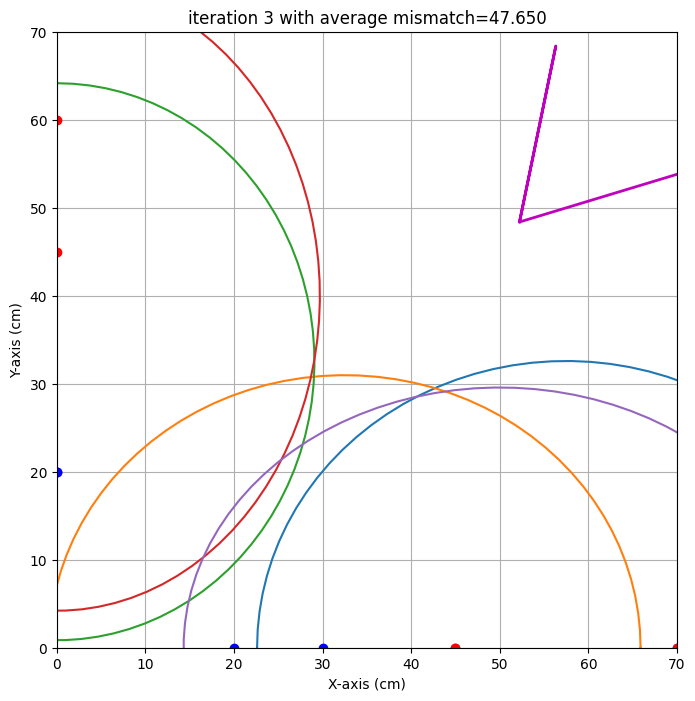

end iteration 3 with average mismatch=47.650


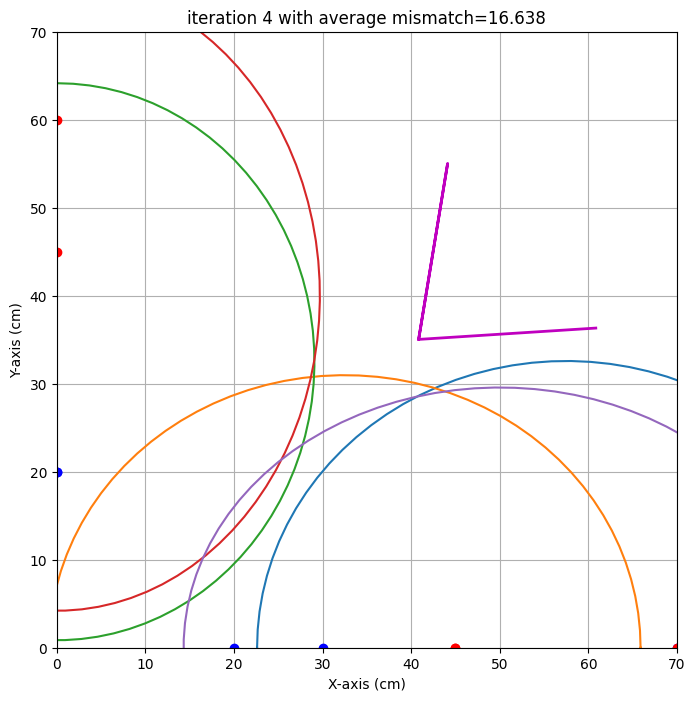

end iteration 4 with average mismatch=16.638


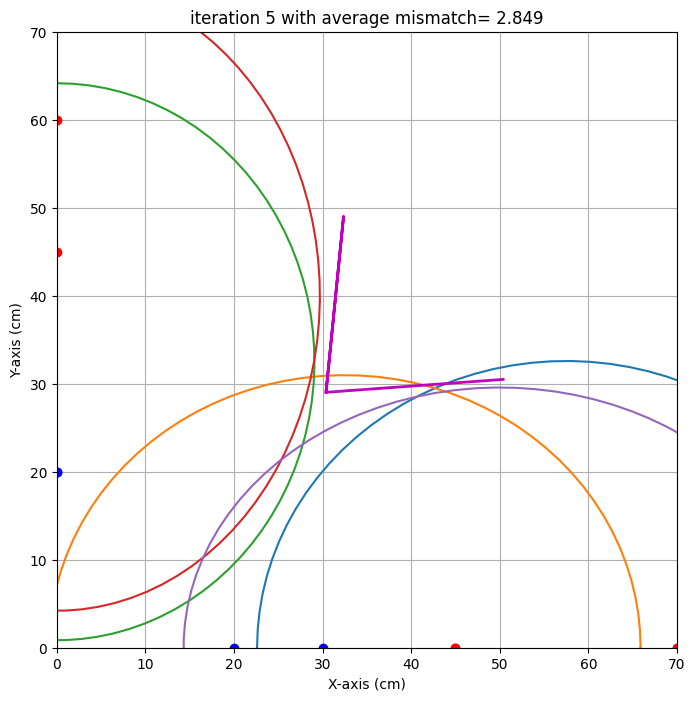

end iteration 5 with average mismatch= 2.849


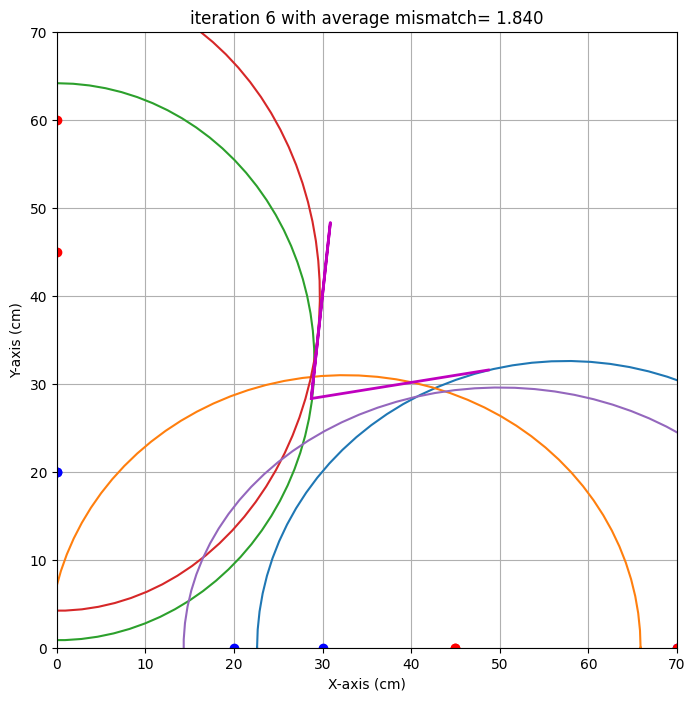

end iteration 6 with average mismatch= 1.840
end iteration 7 with average mismatch= 1.764
end iteration 8 with average mismatch= 1.675
end iteration 9 with average mismatch= 1.661
end iteration 10 with average mismatch= 1.660
end iteration 11 with average mismatch= 1.660
end iteration 12 with average mismatch= 1.639
end iteration 13 with average mismatch= 1.633
end iteration 14 with average mismatch= 1.631
end iteration 15 with average mismatch= 1.630
end iteration 16 with average mismatch= 1.550
end iteration 17 with average mismatch= 1.533
end iteration 18 with average mismatch= 1.529
end iteration 19 with average mismatch= 1.529
end iteration 20 with average mismatch= 1.528
end iteration 21 with average mismatch= 1.528
end iteration 22 with average mismatch= 1.528
end iteration 23 with average mismatch= 1.528
end iteration 24 with average mismatch= 1.528
end iteration 25 with average mismatch= 1.528
end iteration 26 with average mismatch= 1.528
end iteration 27 with average mismatch

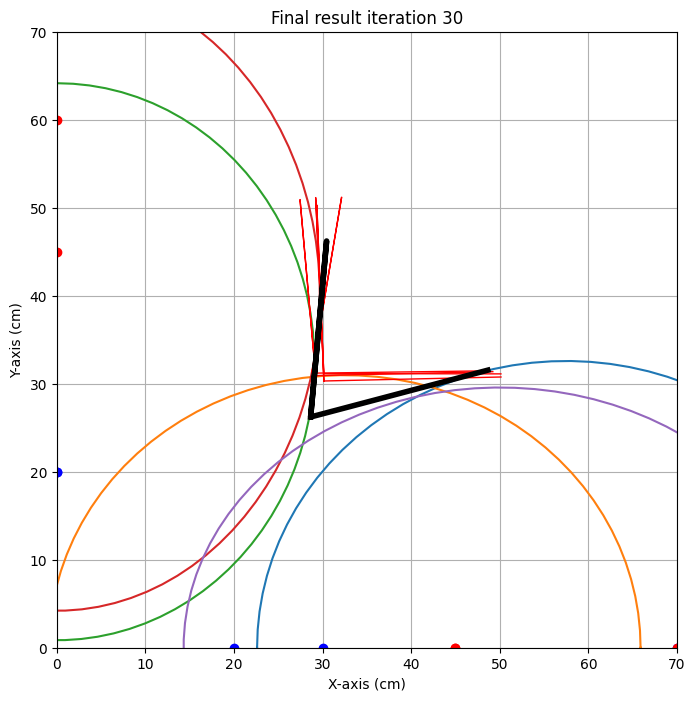

{'alpha': np.float64(14.893247464888175), 'alpha_eps': np.float64(14.993817955439045), 'beta': np.float64(5.1561714826114775), 'beta_eps': np.float64(10.202980257581652), 'x0': np.float64(28.645160601461868), 'x0_eps': np.float64(1.4940015862352425), 'y0': np.float64(26.220435622981288), 'y0_eps': np.float64(4.978067634766315)}
Kimi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  84.2
1   0  30   0  40  71.4
2   0  35   0  45  67.9
3   0  40   0  50  65.5


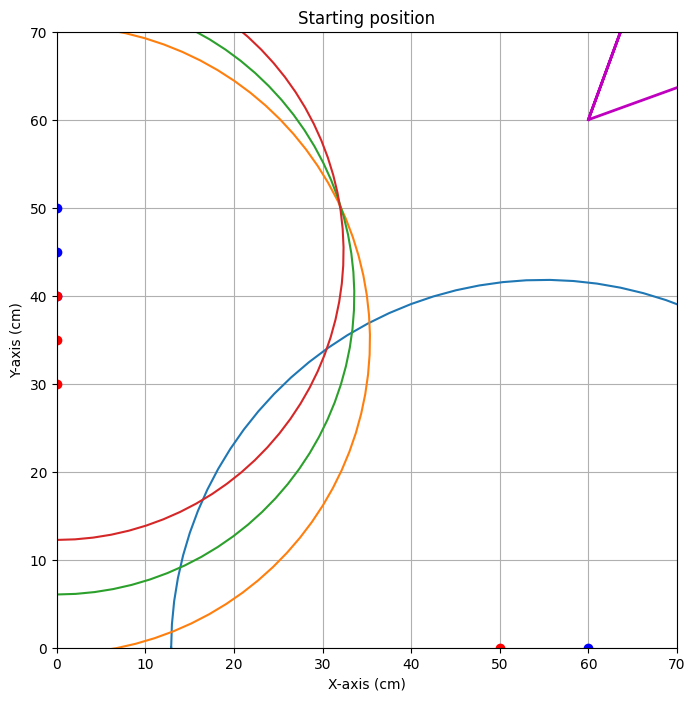


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.813


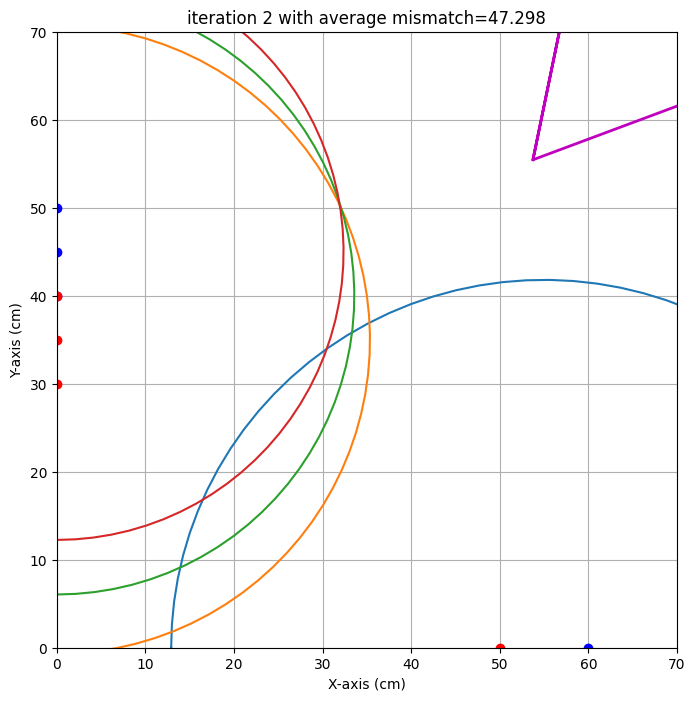

end iteration 2 with average mismatch=47.298


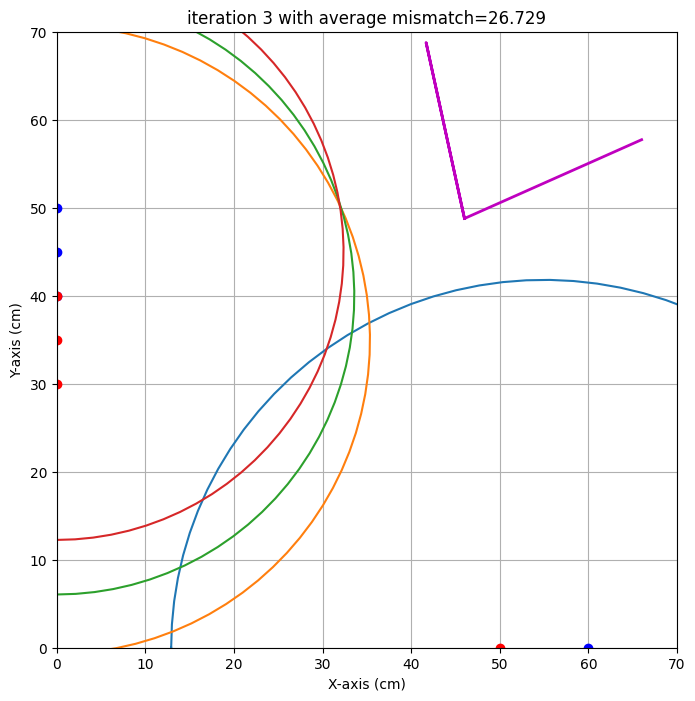

end iteration 3 with average mismatch=26.729


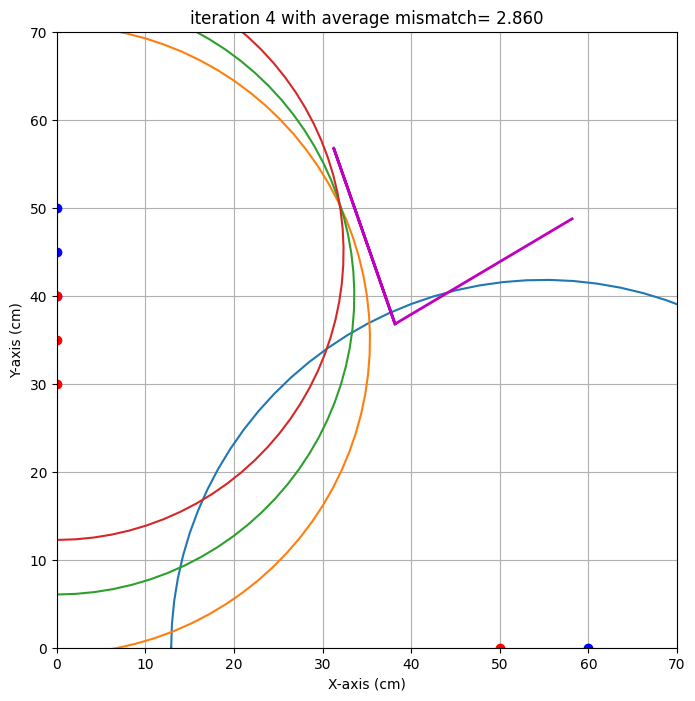

end iteration 4 with average mismatch= 2.860


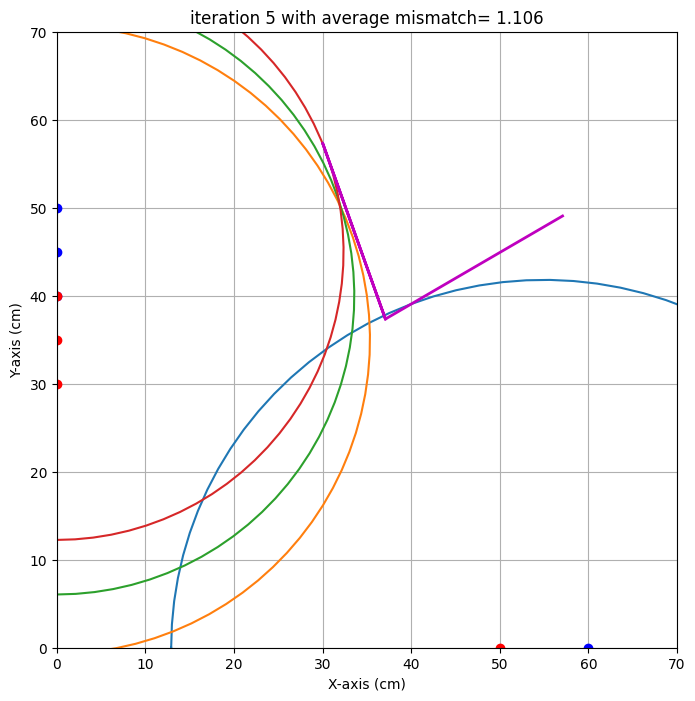

end iteration 5 with average mismatch= 1.106


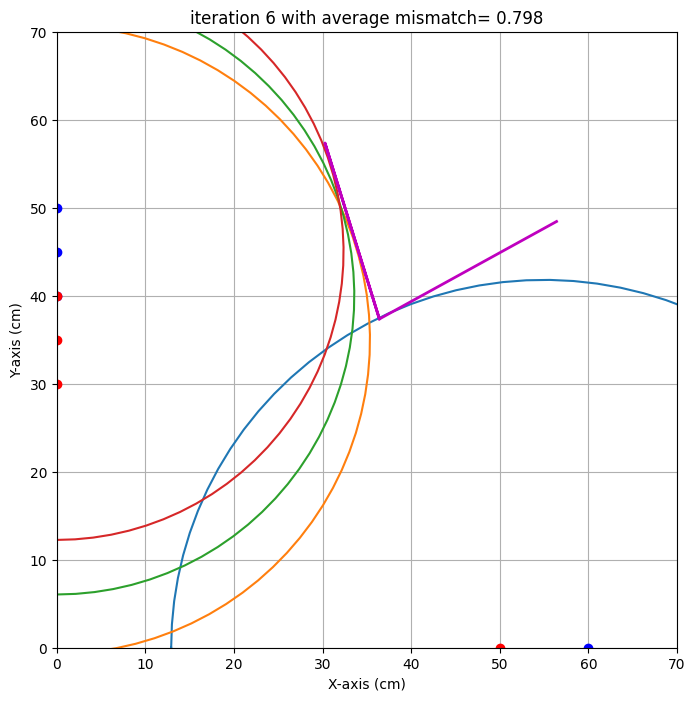

end iteration 6 with average mismatch= 0.798


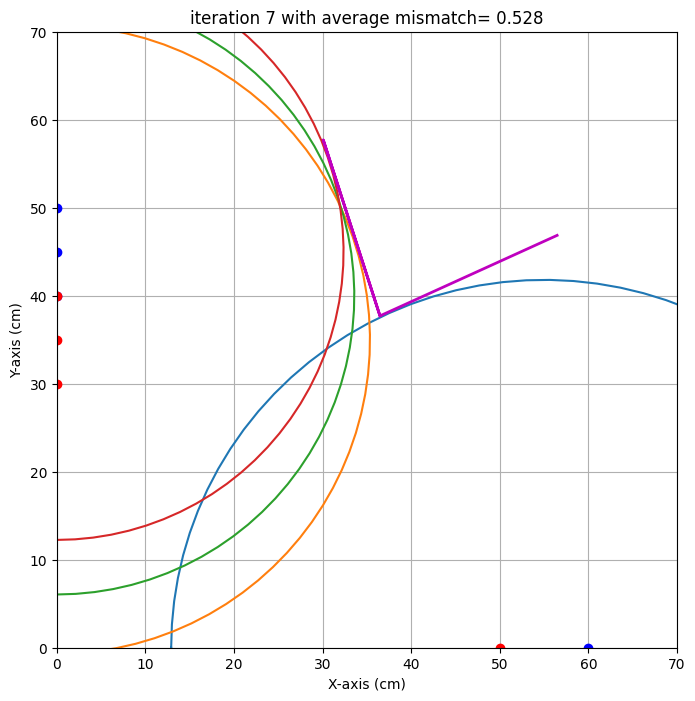

end iteration 7 with average mismatch= 0.528


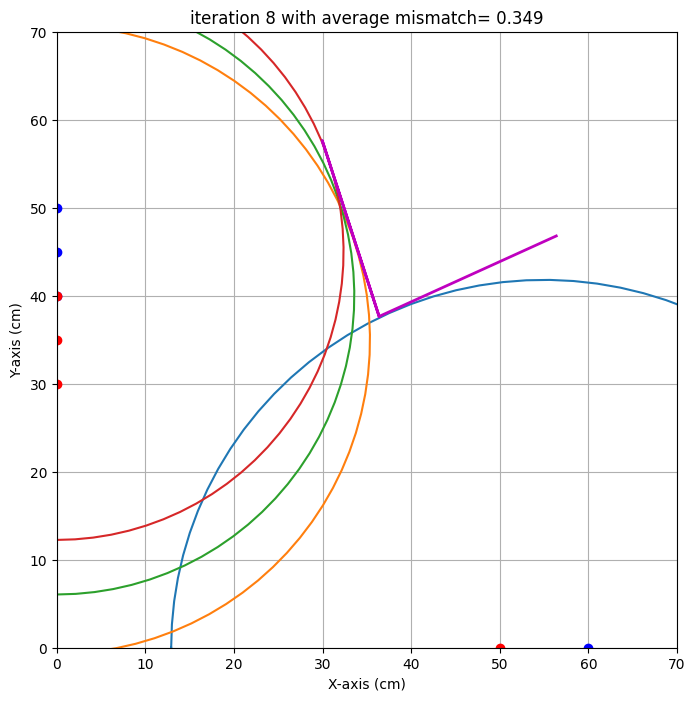

end iteration 8 with average mismatch= 0.349
end iteration 9 with average mismatch= 0.347
end iteration 10 with average mismatch= 0.347
end iteration 11 with average mismatch= 0.347
end iteration 12 with average mismatch= 0.347
end iteration 13 with average mismatch= 0.347
end iteration 14 with average mismatch= 0.347
end iteration 15 with average mismatch= 0.347
end iteration 16 with average mismatch= 0.347
end iteration 17 with average mismatch= 0.347
end iteration 18 with average mismatch= 0.347
end iteration 19 with average mismatch= 0.347
end iteration 20 with average mismatch= 0.347
end iteration 21 with average mismatch= 0.319
end iteration 22 with average mismatch= 0.316
end iteration 23 with average mismatch= 0.315
end iteration 24 with average mismatch= 0.315
end iteration 25 with average mismatch= 0.315
end iteration 26 with average mismatch= 0.315
end iteration 27 with average mismatch= 0.315
end iteration 28 with average mismatch= 0.315
end iteration 29 with average mismat

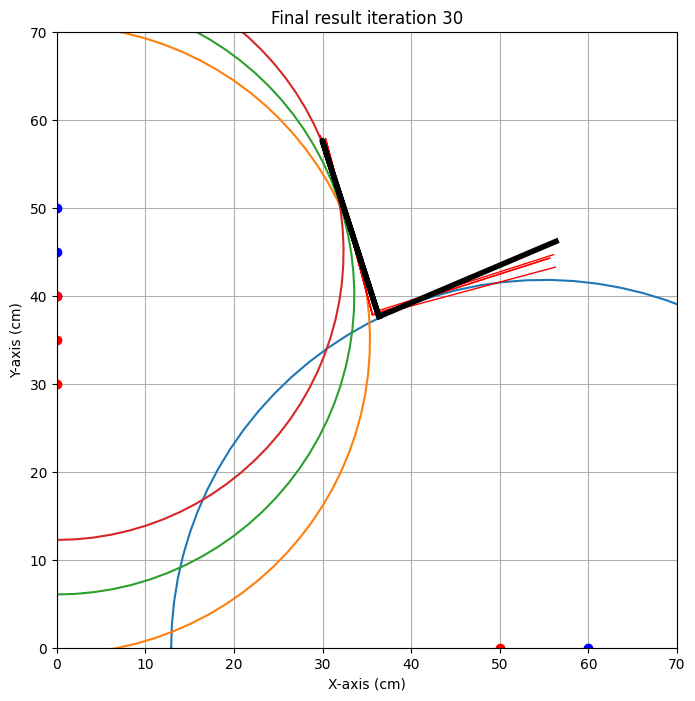

{'alpha': np.float64(23.137996993078087), 'alpha_eps': np.float64(7.9781074104329655), 'beta': np.float64(-17.726397794962708), 'beta_eps': np.float64(2.8754652826721134), 'x0': np.float64(36.351839510558506), 'x0_eps': np.float64(0.7207409240280711), 'y0': np.float64(37.629870951544056), 'y0_eps': np.float64(0.5942524310282877)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Frank 
x0 target is : 35.0. Gevonden waarde: 28.6 cm met een standaardafwijking van 1.5 cm 
y0 target is : 32.0. Gevonden waarde: 26.2 cm met een standaardafwijking van 5.0 cm 
alpha target is : 30.0. Gevonden waarde: 14.9 graden met een standaardafwijking van 15.0 graad 
beta target is : 0.0. Gevonden waarde: 5.2 graden met een standaardafwijking van 10.2 graad 

Kimi 
x0 target is : 35.0. Gevonden waarde: 36.4 cm met een standaardafwijking van 0.7 cm 
y0 target is : 32.0. Gevonden waarde: 37.6 cm met een standaardafwijking van 0.6 cm 
alpha target is : 30.0. Gevonden waarde: 23.1 graden met een standaardafwijking van 8.0 graad 
beta target is : 0.0. Gevonden waarde: -17.7 graden met een standaardafwijking van 2.9 graad 



## Opdracht 8: Iteratie1+.14:20.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.jpeg)


## Iteratie 15:02.

Nu naar iteratie 2

Figuur: ![Alt](iteratie2.jpeg)

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  61.0
1  70   0  30   0  70.2
2   0  45   0  20  56.9
3   0  45   0  70  65.9
4  20   0  70   0  77.1
5   0  70   0  20  73.3


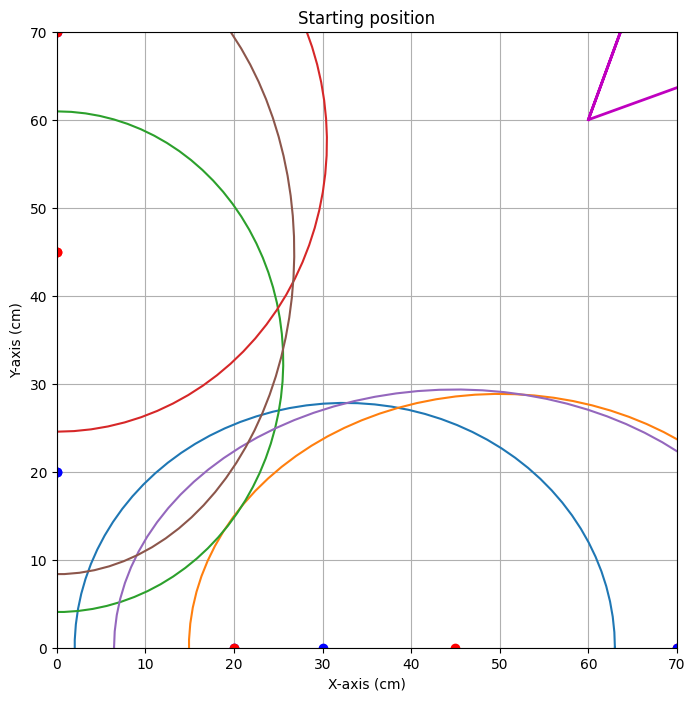


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.422


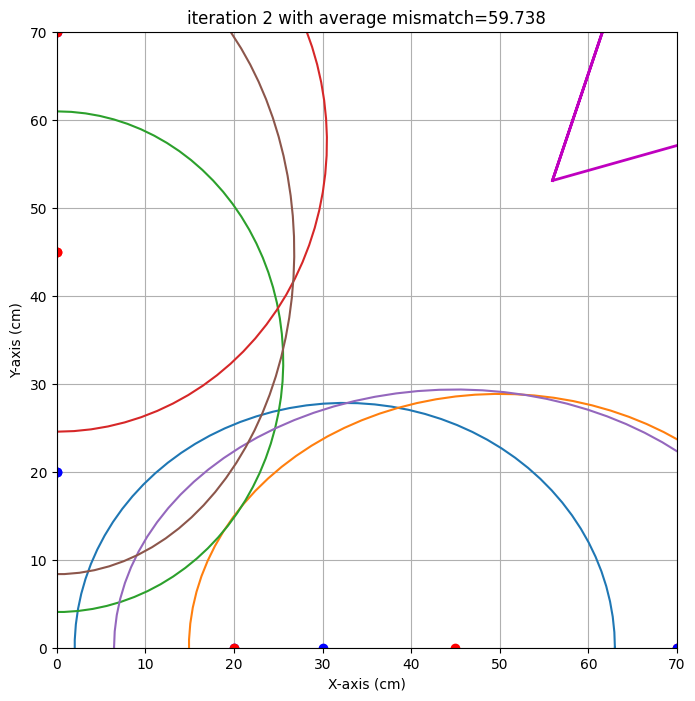

end iteration 2 with average mismatch=59.738


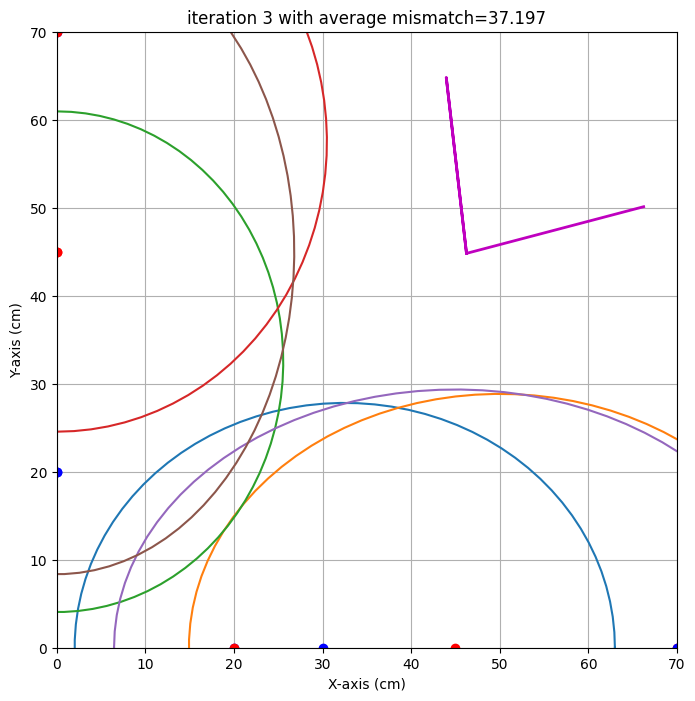

end iteration 3 with average mismatch=37.197


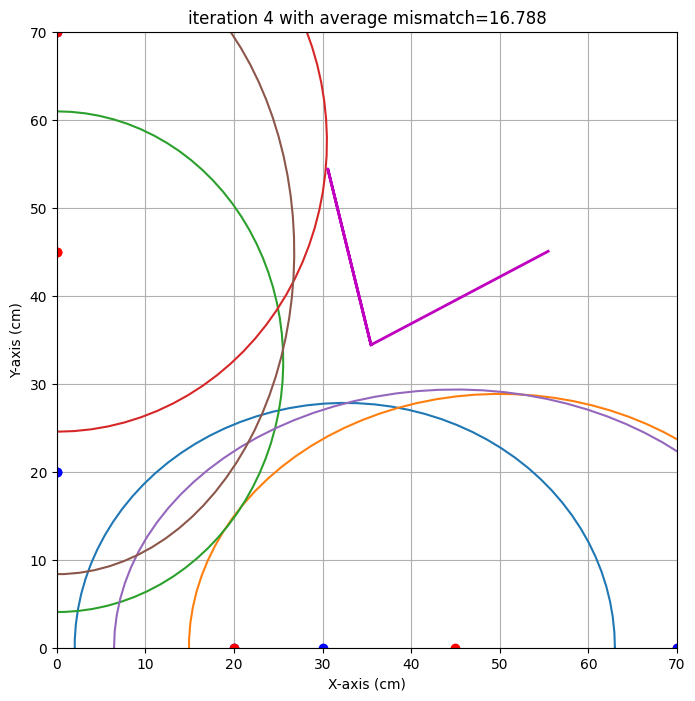

end iteration 4 with average mismatch=16.788


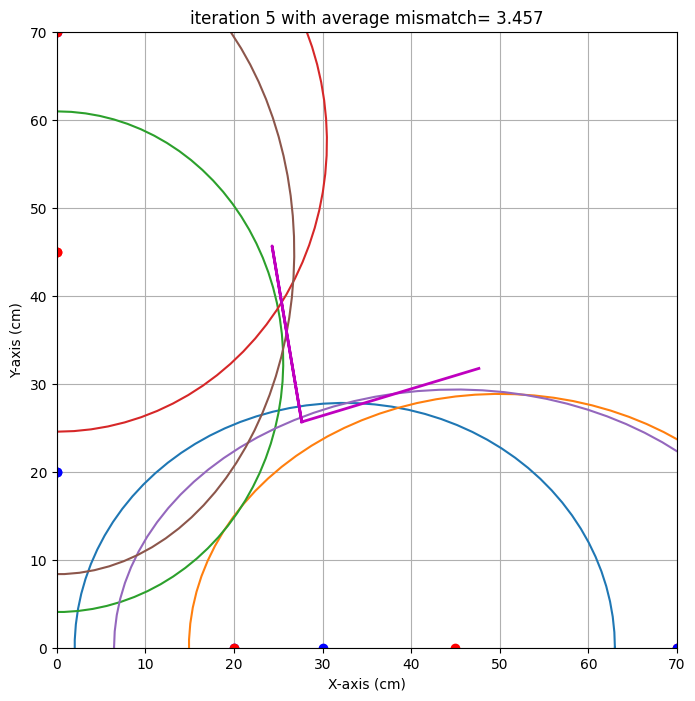

end iteration 5 with average mismatch= 3.457


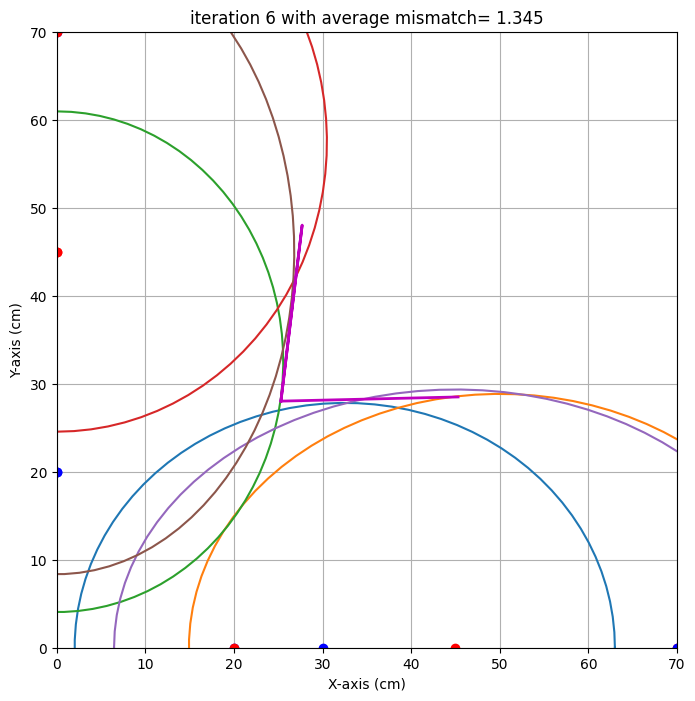

end iteration 6 with average mismatch= 1.345
end iteration 7 with average mismatch= 1.299
end iteration 8 with average mismatch= 1.217
end iteration 9 with average mismatch= 1.180
end iteration 10 with average mismatch= 1.070
end iteration 11 with average mismatch= 1.070
end iteration 12 with average mismatch= 1.070
end iteration 13 with average mismatch= 1.070
end iteration 14 with average mismatch= 1.070
end iteration 15 with average mismatch= 1.070
end iteration 16 with average mismatch= 1.070
end iteration 17 with average mismatch= 1.070
end iteration 18 with average mismatch= 1.070
end iteration 19 with average mismatch= 1.070
end iteration 20 with average mismatch= 1.070
end iteration 21 with average mismatch= 1.028
end iteration 22 with average mismatch= 1.026
end iteration 23 with average mismatch= 1.026
end iteration 24 with average mismatch= 1.026
end iteration 25 with average mismatch= 1.026
end iteration 26 with average mismatch= 1.026
end iteration 27 with average mismatch

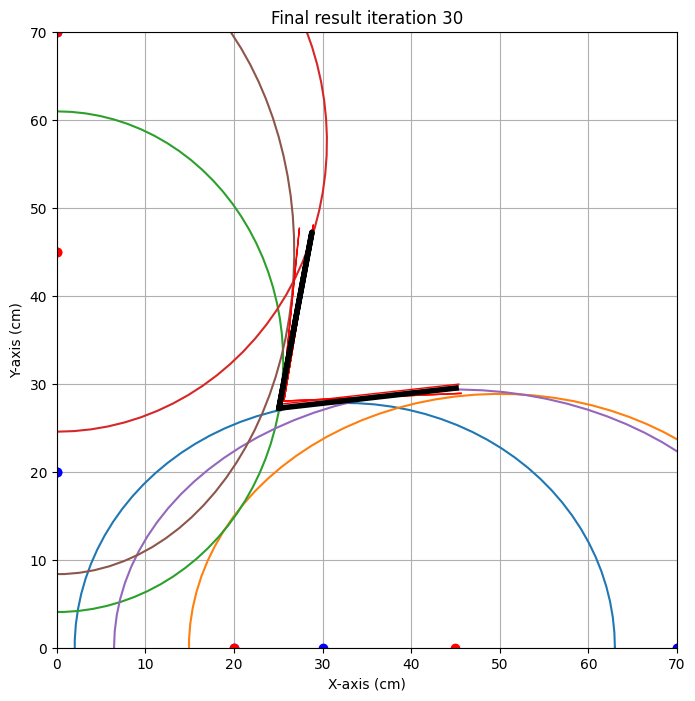

{'alpha': np.float64(6.522753905214447), 'alpha_eps': np.float64(4.029780550620612), 'beta': np.float64(10.556642819856318), 'beta_eps': np.float64(4.87694149105397), 'x0': np.float64(25.067893125700508), 'x0_eps': np.float64(0.5523832130174569), 'y0': np.float64(27.22147726160797), 'y0_eps': np.float64(0.8102772402048295)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.2
1  45   0  70   0  87.5
2   0  40   0  60  82.3
3   0  45   0  70  84.0


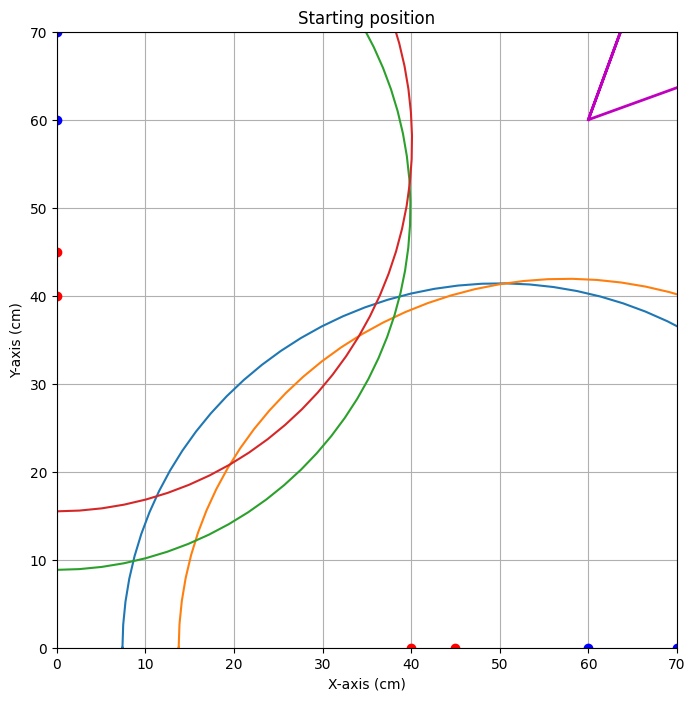


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.962


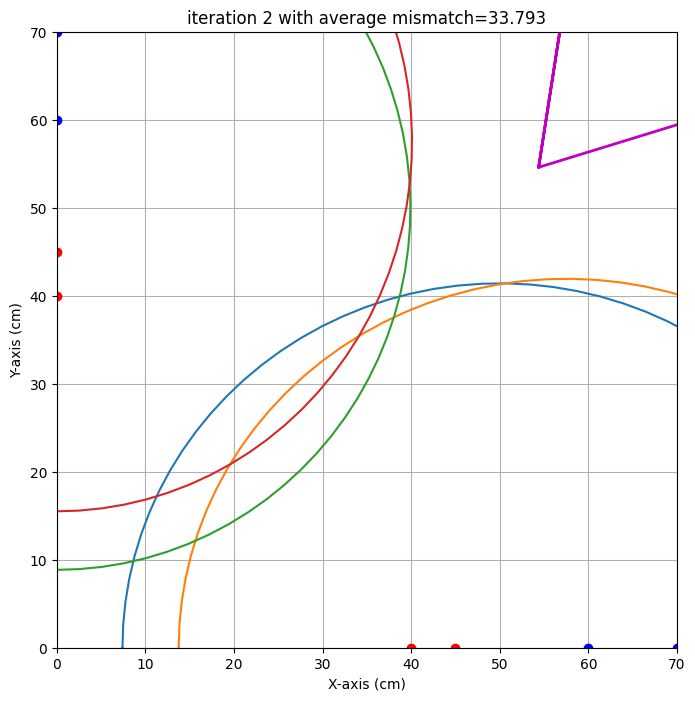

end iteration 2 with average mismatch=33.793


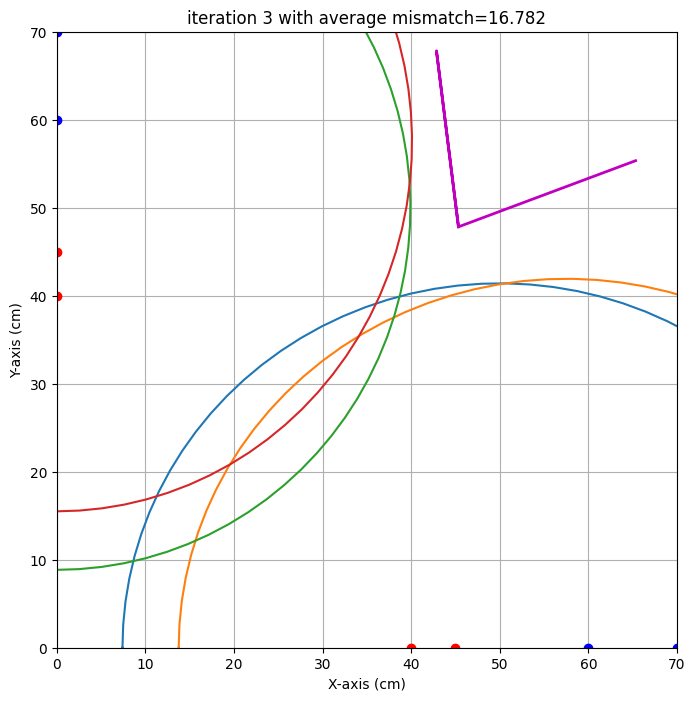

end iteration 3 with average mismatch=16.782


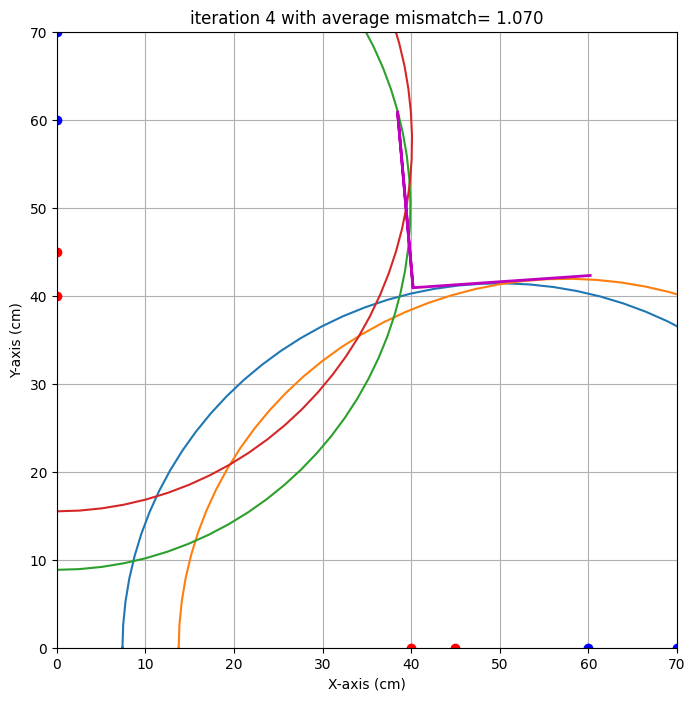

end iteration 4 with average mismatch= 1.070


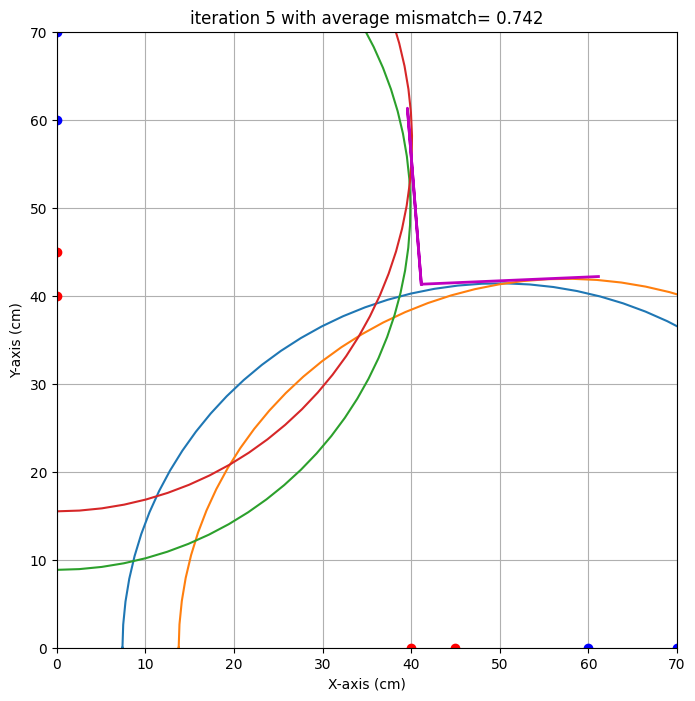

end iteration 5 with average mismatch= 0.742


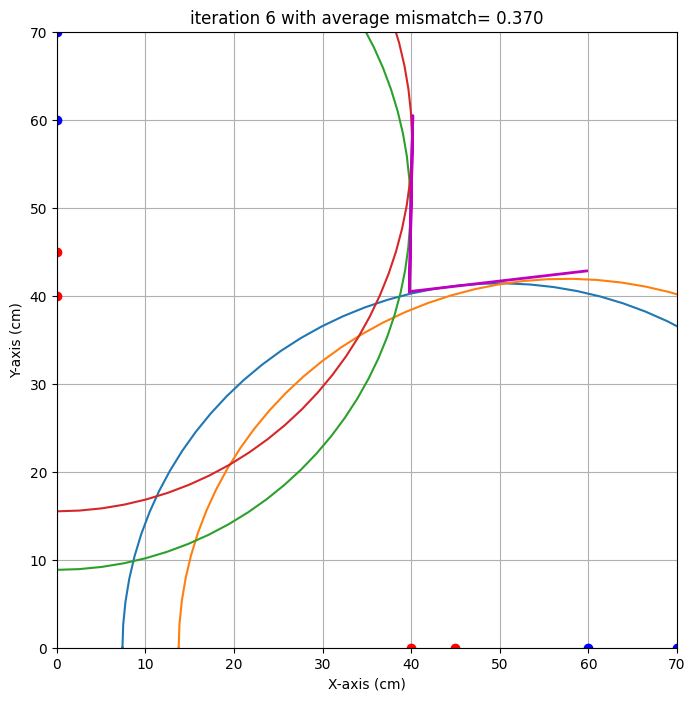

end iteration 6 with average mismatch= 0.370
end iteration 7 with average mismatch= 0.362
end iteration 8 with average mismatch= 0.348


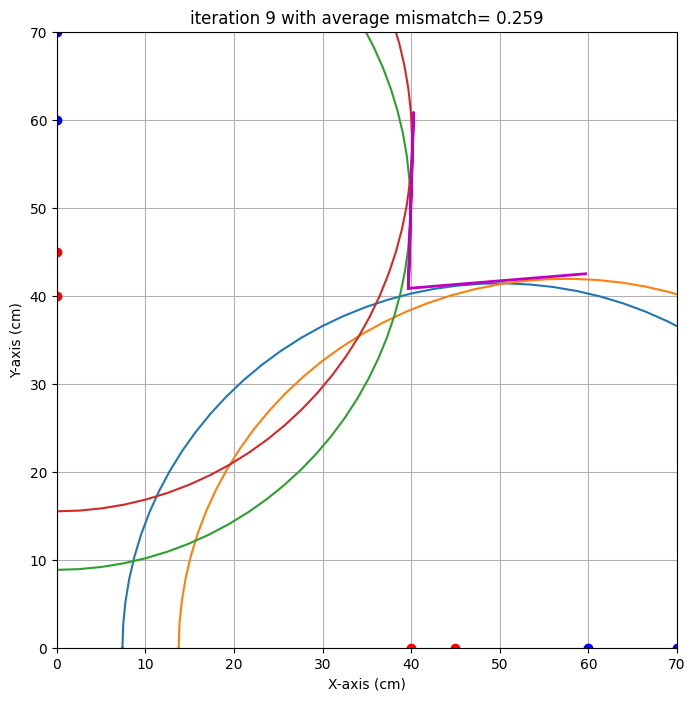

end iteration 9 with average mismatch= 0.259


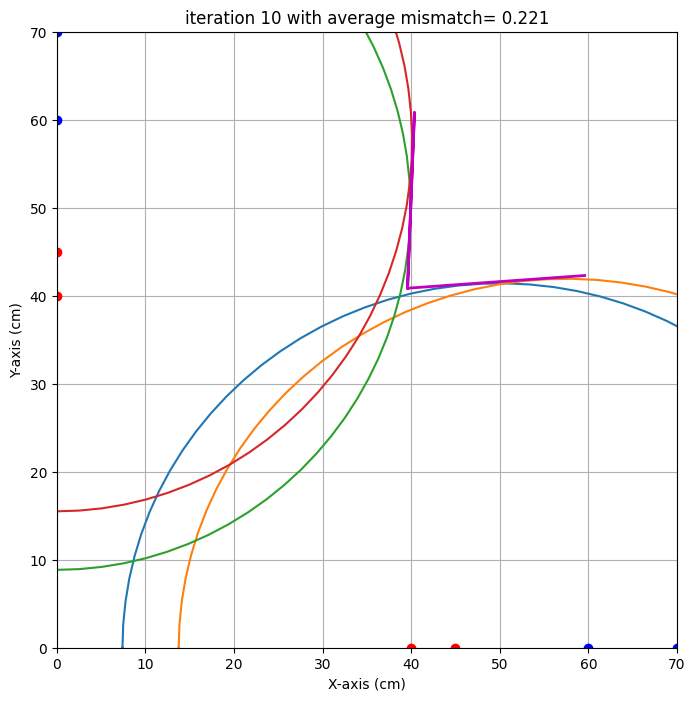

end iteration 10 with average mismatch= 0.221
end iteration 11 with average mismatch= 0.210
end iteration 12 with average mismatch= 0.205
end iteration 13 with average mismatch= 0.204
end iteration 14 with average mismatch= 0.203
end iteration 15 with average mismatch= 0.203
end iteration 16 with average mismatch= 0.203
end iteration 17 with average mismatch= 0.203
end iteration 18 with average mismatch= 0.203
end iteration 19 with average mismatch= 0.203
end iteration 20 with average mismatch= 0.203
end iteration 21 with average mismatch= 0.203
end iteration 22 with average mismatch= 0.203
end iteration 23 with average mismatch= 0.203
end iteration 24 with average mismatch= 0.203
end iteration 25 with average mismatch= 0.203
end iteration 26 with average mismatch= 0.203
end iteration 27 with average mismatch= 0.203
end iteration 28 with average mismatch= 0.203
end iteration 29 with average mismatch= 0.203
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

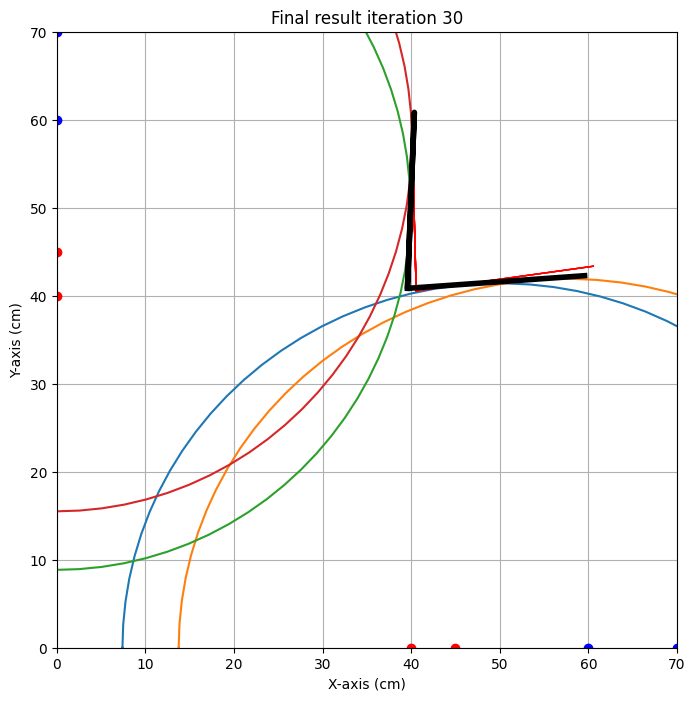

{'alpha': np.float64(4.1114984398685985), 'alpha_eps': np.float64(3.853090279130827), 'beta': np.float64(2.229679943778825), 'beta_eps': np.float64(3.7042278528126187), 'x0': np.float64(39.57725950892243), 'x0_eps': np.float64(0.9845649055445094), 'y0': np.float64(40.83880010801704), 'y0_eps': np.float64(0.28555551910286425)}
locatie 1 
x0 target is : 22.0. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.6 cm 
y0 target is : 26.0. Gevonden waarde: 27.2 cm met een standaardafwijking van 0.8 cm 
alpha target is : 10.0. Gevonden waarde: 6.5 graden met een standaardafwijking van 4.0 graad 
beta target is : 20.0. Gevonden waarde: 10.6 graden met een standaardafwijking van 4.9 graad 

locatie 2 
x0 target is : 39.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 1.0 cm 
y0 target is : 39.0. Gevonden waarde: 40.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 5.0. Gevonden waarde: 4.1 graden met een standaardafwijking van 3.9 graad 
beta target is : 5.0. Gevond

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie 1

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':22,
                    'y0':26,
                    'alpha' : 10,
                    'beta' : 20,},
            'locatie 2':{'x0':39,
                     'y0':39,
                     'alpha' : 5,
                     'beta' : 5}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45, 0, 20, 0, 61.0],
    [70, 0, 30, 0, 70.2],
    [0, 45, 0, 20, 56.9],
    [0, 45, 0, 70, 65.9],
    [20, 0, 70, 0, 77.1],
    [0, 70, 0, 20, 73.3],
    ]),
        'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -]
    [40, 0, 60, 0, 85.2],
    [45, 0, 70, 0, 87.5],
    #[0, 45, 0, 20, -]
    [0, 40, 0, 60, 82.3],
    [0, 45, 0, 70, 84.0]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  71.6
1  45   0  70   0  78.3
2   0  45   0  20  89.0
3   0  45   0  70  85.4
4  20   0  70   0  88.4
5   0  70   0  20  93.6
6   0  25   0  45  86.4
7   0  50   0  65  83.5
8  50   0  65   0  76.0


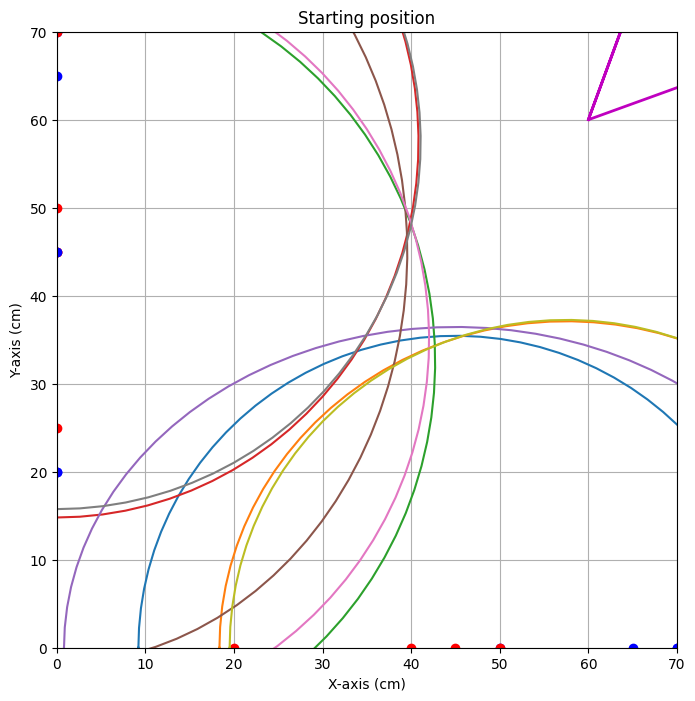


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.270


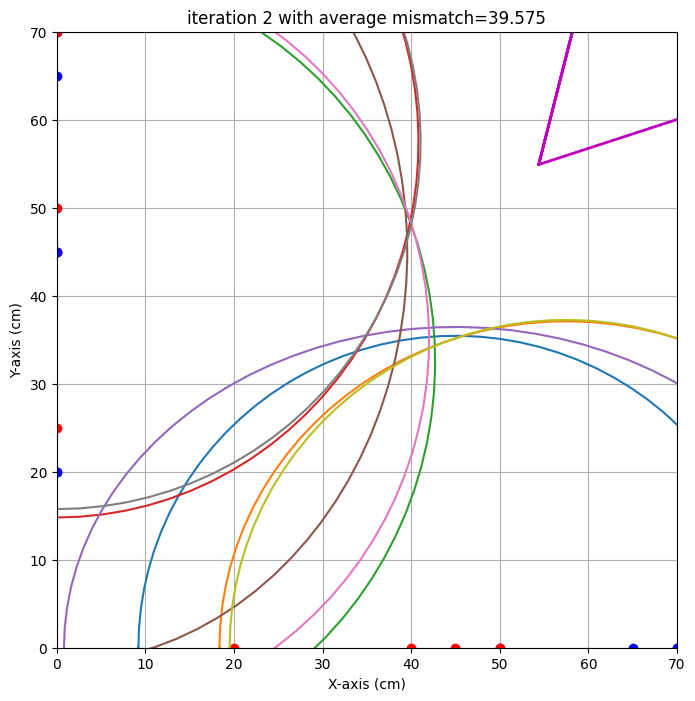

end iteration 2 with average mismatch=39.575


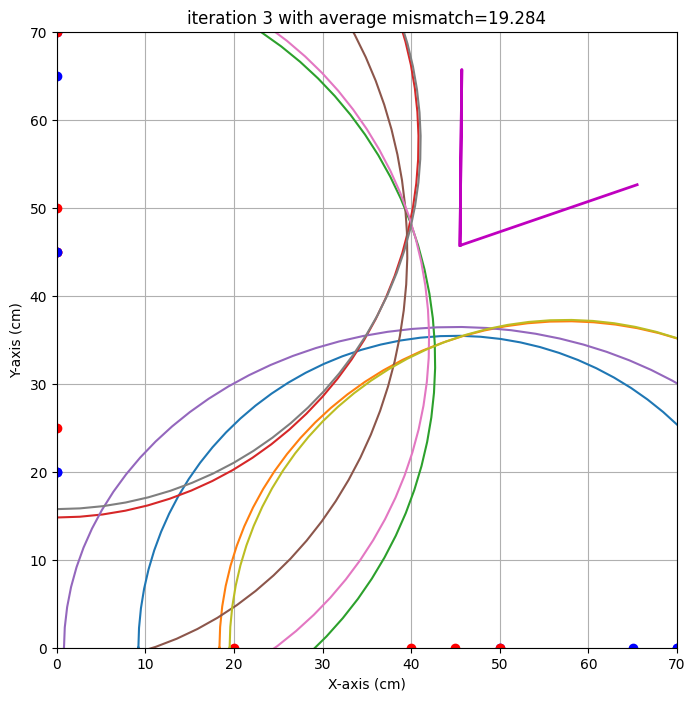

end iteration 3 with average mismatch=19.284


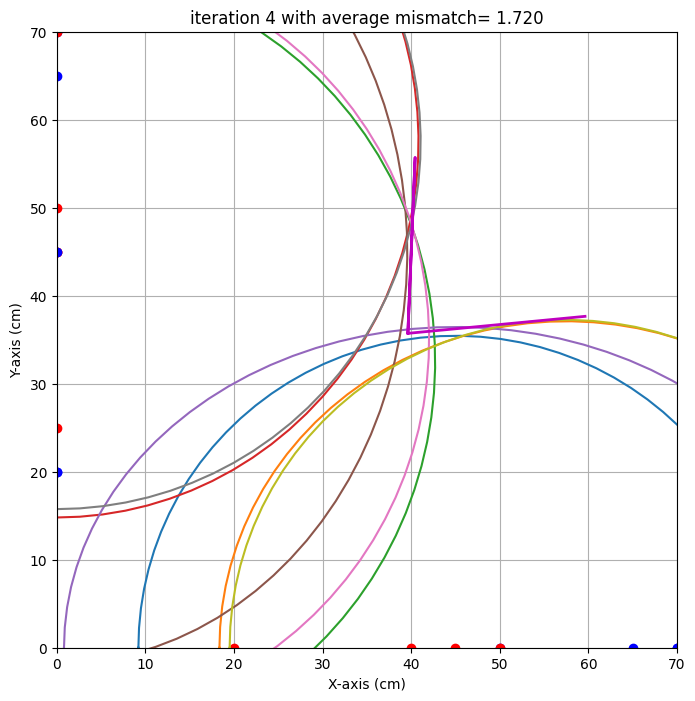

end iteration 4 with average mismatch= 1.720
end iteration 5 with average mismatch= 1.624
end iteration 6 with average mismatch= 1.571
end iteration 7 with average mismatch= 1.501
end iteration 8 with average mismatch= 1.496
end iteration 9 with average mismatch= 1.496
end iteration 10 with average mismatch= 1.496
end iteration 11 with average mismatch= 1.496
end iteration 12 with average mismatch= 1.496
end iteration 13 with average mismatch= 1.496
end iteration 14 with average mismatch= 1.496
end iteration 15 with average mismatch= 1.496
end iteration 16 with average mismatch= 1.496
end iteration 17 with average mismatch= 1.496
end iteration 18 with average mismatch= 1.496
end iteration 19 with average mismatch= 1.496
end iteration 20 with average mismatch= 1.496
end iteration 21 with average mismatch= 1.476
end iteration 22 with average mismatch= 1.476
end iteration 23 with average mismatch= 1.469
end iteration 24 with average mismatch= 1.468
end iteration 25 with average mismatch= 

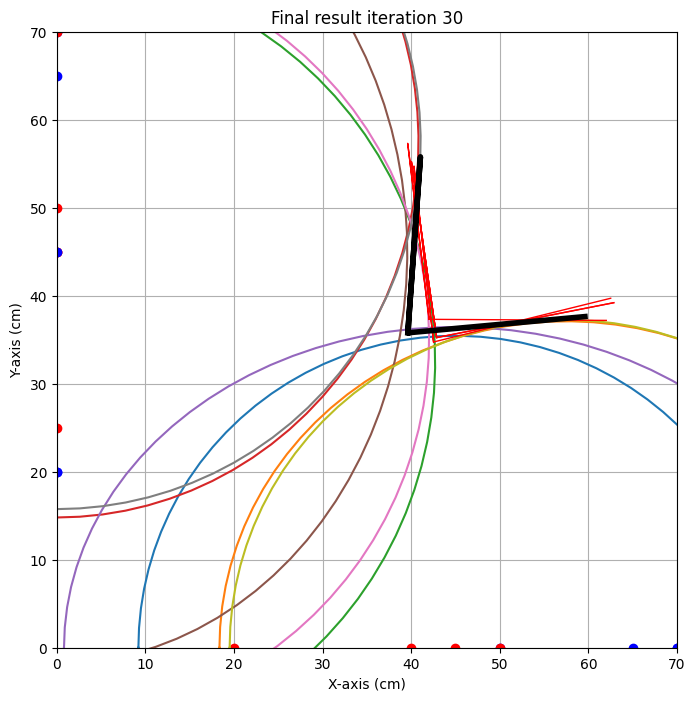

{'alpha': np.float64(5.264389626124844), 'alpha_eps': np.float64(8.69168342603202), 'beta': np.float64(4.074348626746332), 'beta_eps': np.float64(12.201590004200598), 'x0': np.float64(39.61870699508304), 'x0_eps': np.float64(3.256230070278633), 'y0': np.float64(35.78615086118815), 'y0_eps': np.float64(1.5318610054233304)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.1
1  45   0  70   0  86.8
2   0  40   0  60  88.5
3   0  45   0  70  92.5
4   0  50   0  65  89.0
5  50   0  65   0  84.5


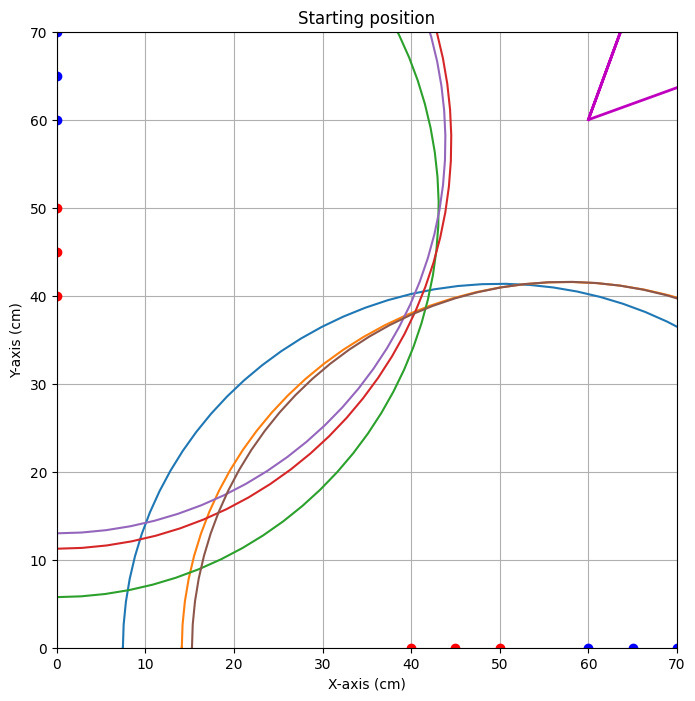


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.258


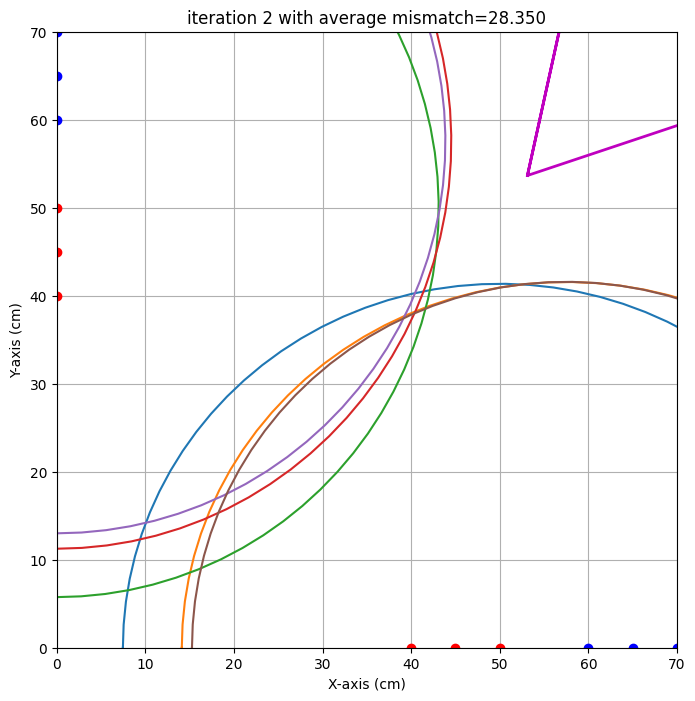

end iteration 2 with average mismatch=28.350


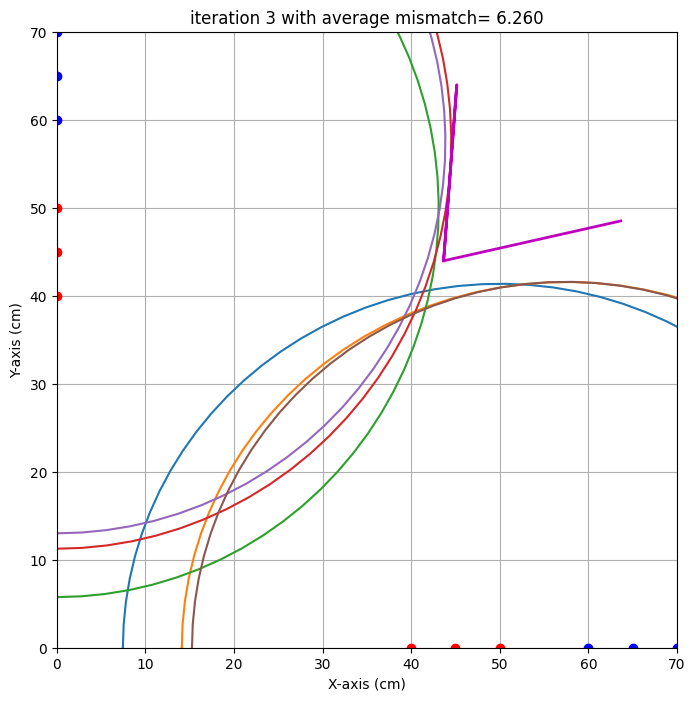

end iteration 3 with average mismatch= 6.260


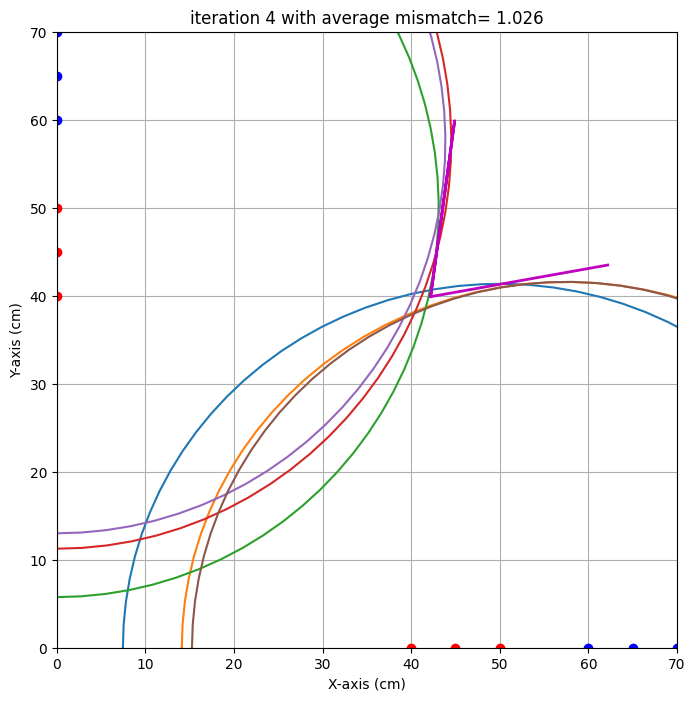

end iteration 4 with average mismatch= 1.026


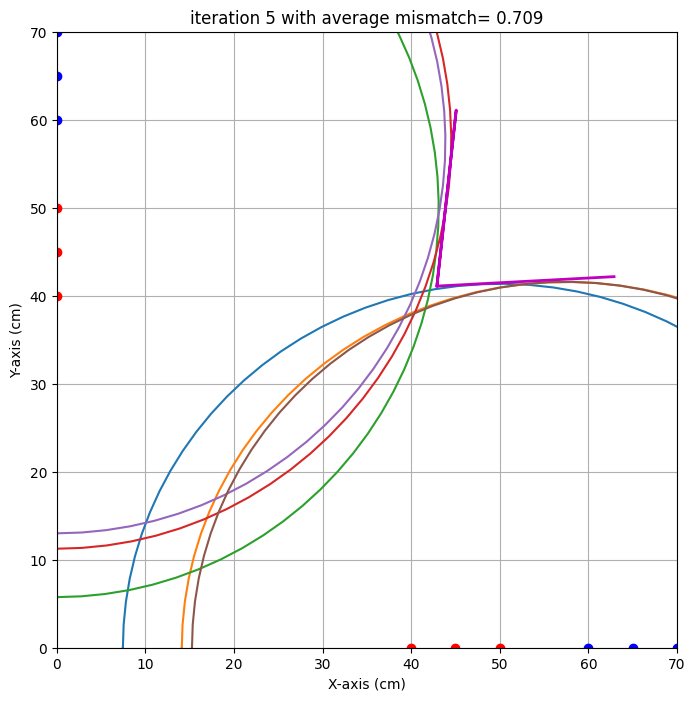

end iteration 5 with average mismatch= 0.709


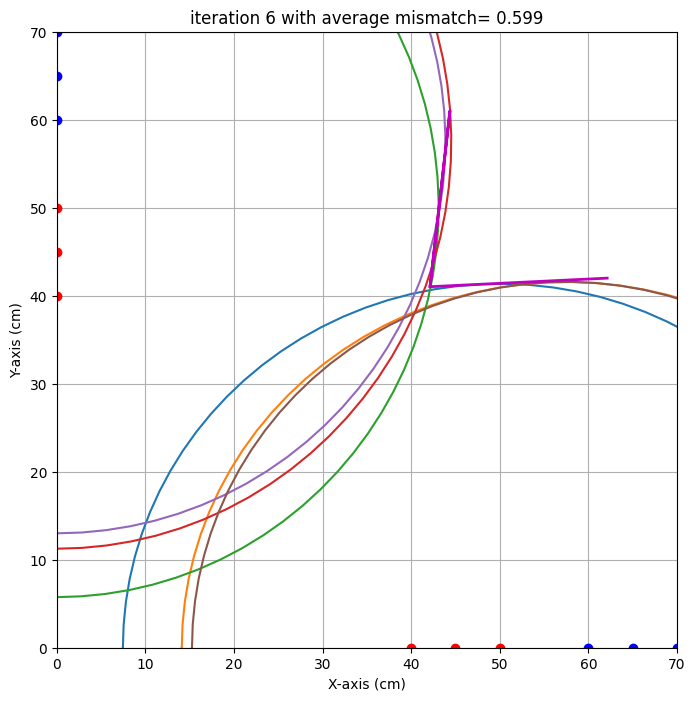

end iteration 6 with average mismatch= 0.599
end iteration 7 with average mismatch= 0.553
end iteration 8 with average mismatch= 0.524
end iteration 9 with average mismatch= 0.510
end iteration 10 with average mismatch= 0.488
end iteration 11 with average mismatch= 0.468
end iteration 12 with average mismatch= 0.453
end iteration 13 with average mismatch= 0.450
end iteration 14 with average mismatch= 0.450
end iteration 15 with average mismatch= 0.449
end iteration 16 with average mismatch= 0.449
end iteration 17 with average mismatch= 0.449
end iteration 18 with average mismatch= 0.449
end iteration 19 with average mismatch= 0.449
end iteration 20 with average mismatch= 0.414
end iteration 21 with average mismatch= 0.394
end iteration 22 with average mismatch= 0.370
end iteration 23 with average mismatch= 0.367
end iteration 24 with average mismatch= 0.367
end iteration 25 with average mismatch= 0.367
end iteration 26 with average mismatch= 0.367
end iteration 27 with average mismatch

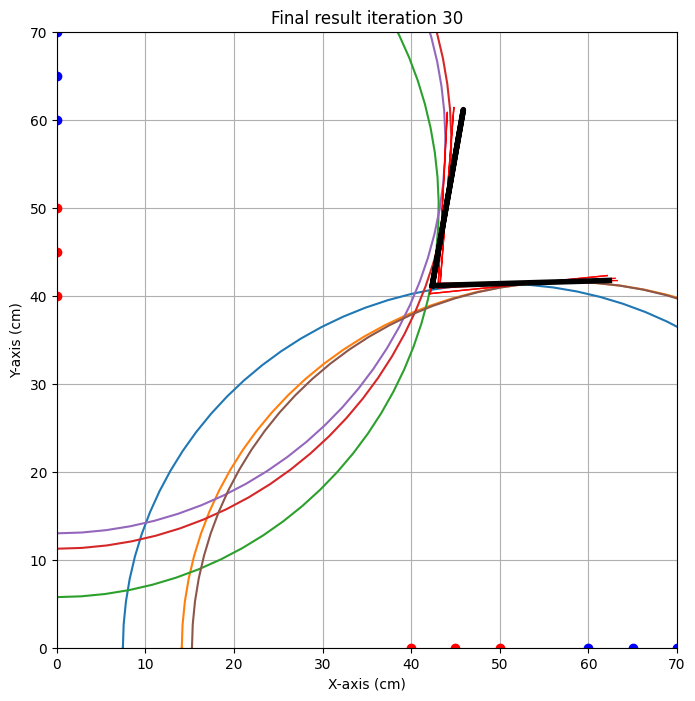

{'alpha': np.float64(1.6812398991499766), 'alpha_eps': np.float64(4.1733287818939395), 'beta': np.float64(9.97859186257514), 'beta_eps': np.float64(6.990090980631765), 'x0': np.float64(42.374432420169505), 'x0_eps': np.float64(0.8999693568789766), 'y0': np.float64(41.15011218371425), 'y0_eps': np.float64(0.9106775850958186)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 3.3 cm 
y0 target is : 32.0. Gevonden waarde: 35.8 cm met een standaardafwijking van 1.5 cm 
alpha target is : 10.0. Gevonden waarde: 5.3 graden met een standaardafwijking van 8.7 graad 
beta target is : 10.0. Gevonden waarde: 4.1 graden met een standaardafwijking van 12.2 graad 

locatie 2 
x0 target is : 42.0. Gevonden waarde: 42.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 38.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 0.9 cm 
alpha target is : 15.0. Gevonden waarde: 1.7 graden met een standaardafwijking van 4.2 graad 
beta target is : 10.0. Gevon

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie nummer 2

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,
                    'y0':32,
                    'alpha' : 10,
                    'beta' : 10,},
           'locatie 2':{'x0':42,
                    'y0':38,
                    'alpha' : 15,
                    'beta' : 10}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, x],
    [40, 0, 50, 0, 71.6],
    [45, 0, 70, 0, 78.3],
    [0, 45, 0, 20, 89.0],
    [0, 45, 0, 70, 85.4],
    [20, 0, 70, 0, 88.4],
    [0, 70, 0, 20, 93.6],
    [0, 25, 0, 45, 86.4],
    #[25, 0, 45, 0, -],
    [0, 50, 0, 65, 83.5],
    [50, 0, 65, 0, 76.0]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -],
    [40, 0, 60, 0, 85.1],
    [45, 0, 70, 0, 86.8],
    #[0, 45, 0, 20, -],
    [0, 40, 0, 60, 88.5],
    [0, 45, 0, 70, 92.5],
    #[20, 0, 70, 0, -],
    #[0, 70, 0, 20, -],
    #[0, 25, 0 45, -],
    [0, 50, 0, 65, 89.0],
    #[25, 0, 45, 0, -],
    [50, 0, 65, 0, 84.5]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  57.7
1  70   0  30   0  67.1
2   0  45   0  20  53.3
3  20   0  70   0  72.8
4   0  25   0  45  50.2
5  25   0  45   0  55.8


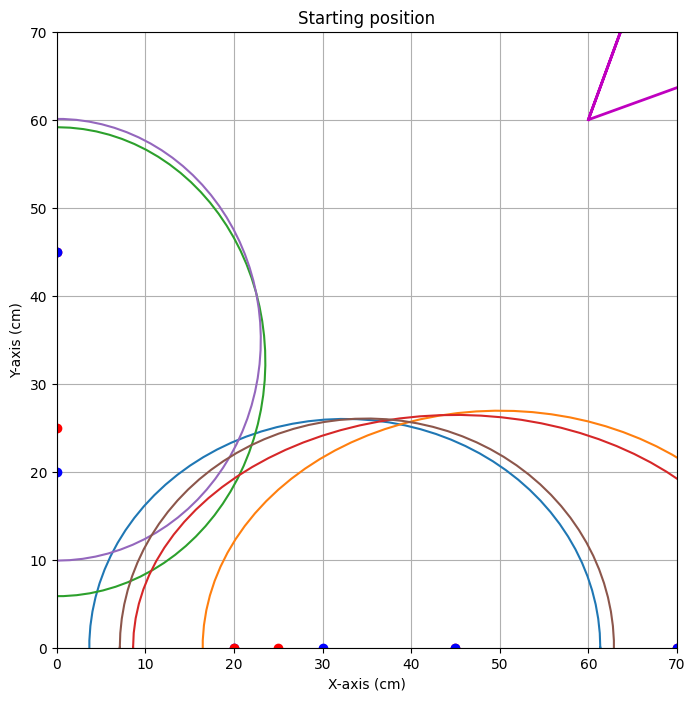


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.881


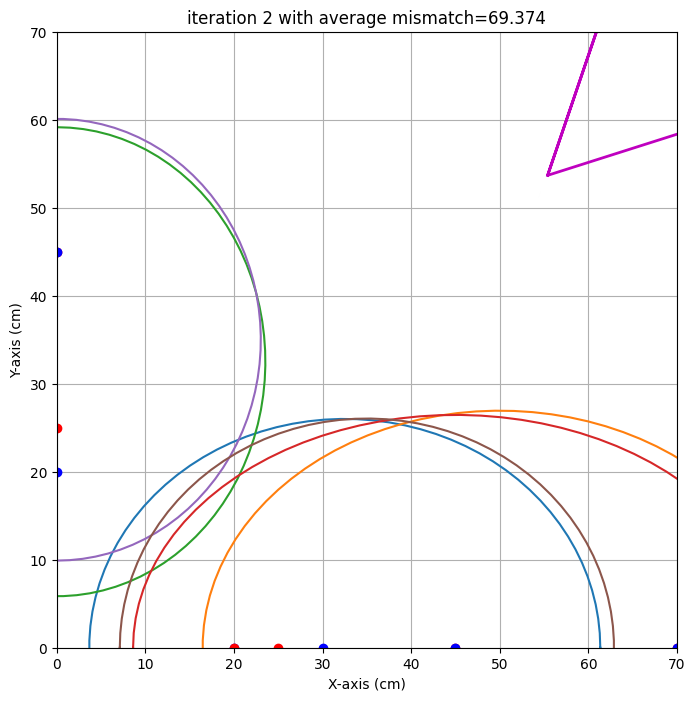

end iteration 2 with average mismatch=69.374


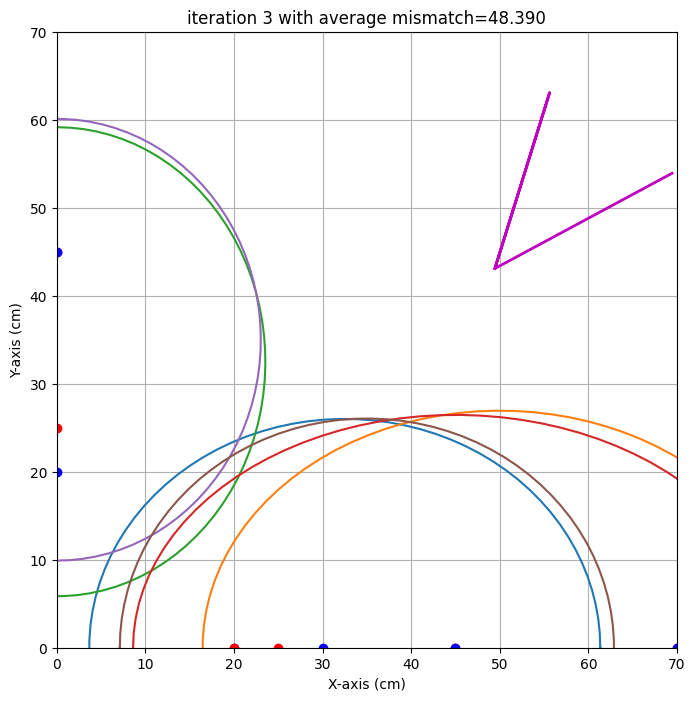

end iteration 3 with average mismatch=48.390


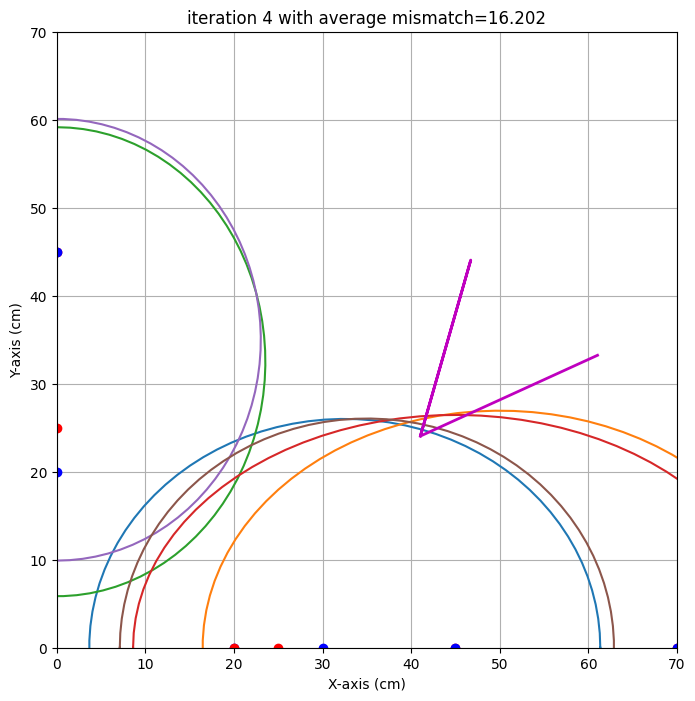

end iteration 4 with average mismatch=16.202


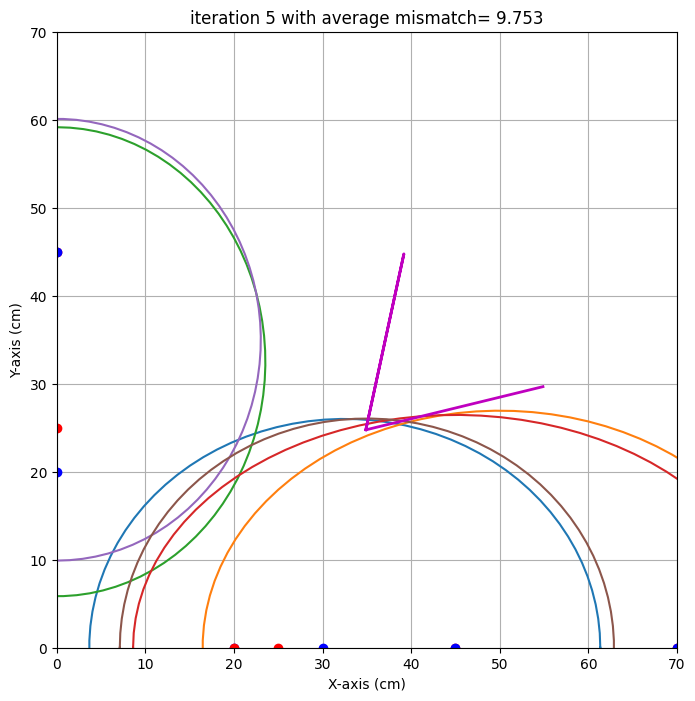

end iteration 5 with average mismatch= 9.753


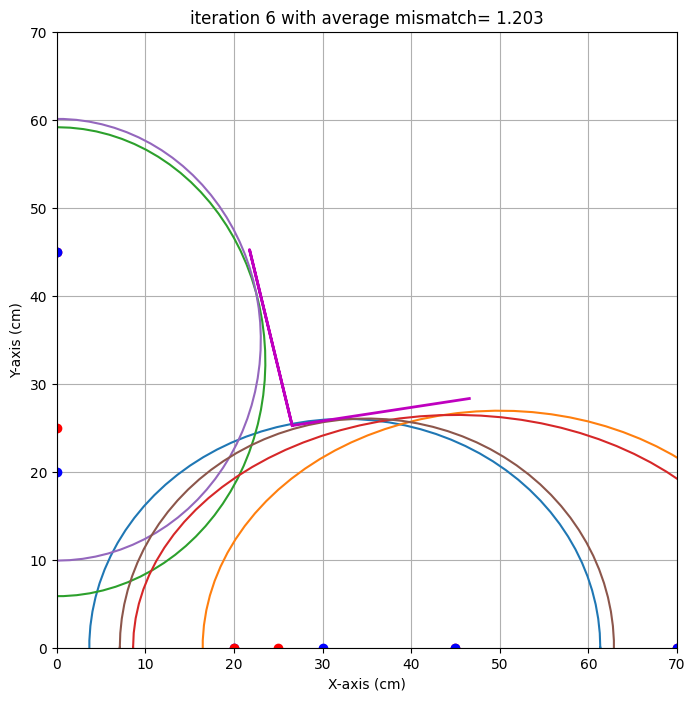

end iteration 6 with average mismatch= 1.203


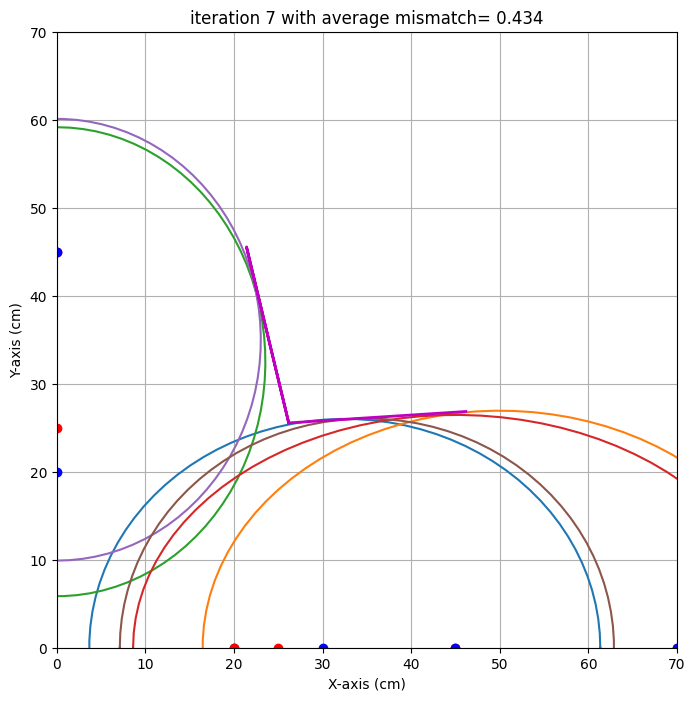

end iteration 7 with average mismatch= 0.434


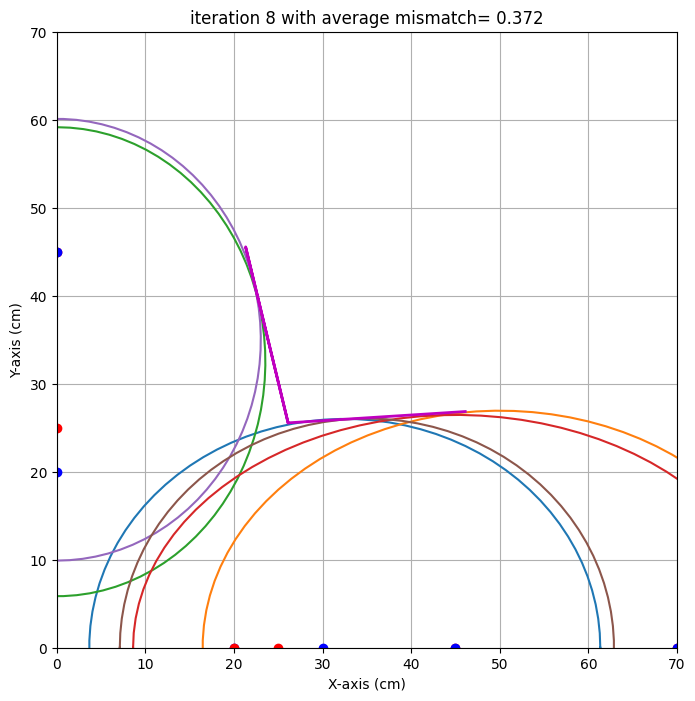

end iteration 8 with average mismatch= 0.372
end iteration 9 with average mismatch= 0.343
end iteration 10 with average mismatch= 0.340
end iteration 11 with average mismatch= 0.340
end iteration 12 with average mismatch= 0.340
end iteration 13 with average mismatch= 0.340
end iteration 14 with average mismatch= 0.340
end iteration 15 with average mismatch= 0.340
end iteration 16 with average mismatch= 0.340
end iteration 17 with average mismatch= 0.340
end iteration 18 with average mismatch= 0.340
end iteration 19 with average mismatch= 0.340
end iteration 20 with average mismatch= 0.340
end iteration 21 with average mismatch= 0.340
end iteration 22 with average mismatch= 0.340
end iteration 23 with average mismatch= 0.340
end iteration 24 with average mismatch= 0.328
end iteration 25 with average mismatch= 0.323
end iteration 26 with average mismatch= 0.322
end iteration 27 with average mismatch= 0.322
end iteration 28 with average mismatch= 0.322
end iteration 29 with average mismat

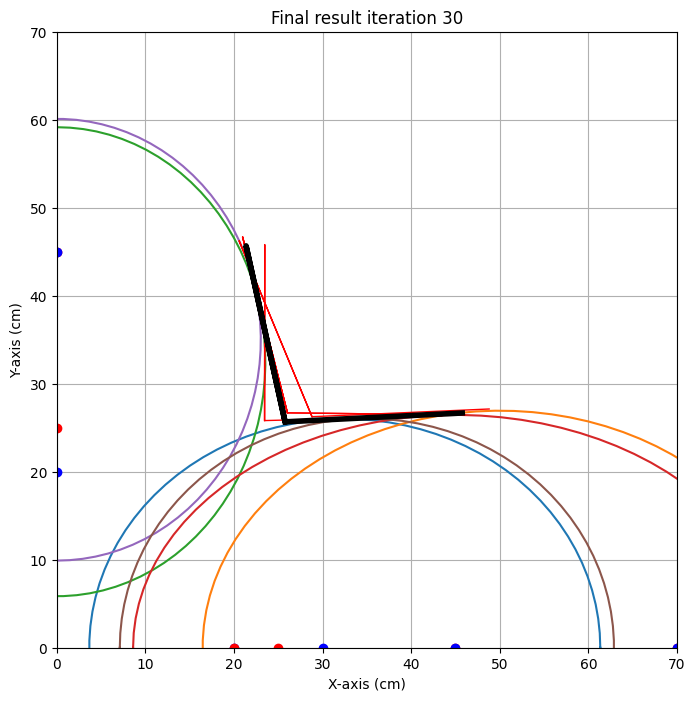

{'alpha': np.float64(2.8730225576633925), 'alpha_eps': np.float64(3.554346428118417), 'beta': np.float64(-12.43124773647252), 'beta_eps': np.float64(12.492708042802837), 'x0': np.float64(25.76339952430016), 'x0_eps': np.float64(3.0377425402215934), 'y0': np.float64(25.669046616266048), 'y0_eps': np.float64(1.020361654316229)}
test locatie 
x0 target is : 26.0. Gevonden waarde: 25.8 cm met een standaardafwijking van 3.0 cm 
y0 target is : 25.0. Gevonden waarde: 25.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : 1.0. Gevonden waarde: 2.9 graden met een standaardafwijking van 3.6 graad 
beta target is : -13.0. Gevonden waarde: -12.4 graden met een standaardafwijking van 12.5 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  26,
                    'y0':  25,
                    'alpha' : 1,
                    'beta' : -13
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [45, 0, 20, 0, 57.7],
                    #[45, 0, 70, 0, -],
                    [70, 0, 30, 0, 67.1],
                    [0, 45, 0, 20, 53.3],
                    #[0, 45, 0, 70, -],
                    #[0, 70, 0, 30, -]
                    [20, 0, 70, 0, 72.8],
                    #[0, 70, 0, 20, -]
                    [0, 25, 0, 45, 50.2],
                    #,
                    #[0, 50, 0, 65, -],
                    [25, 0, 45, 0, 55.8],
                    #[50, 0, 65, 0, -]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

## Iteratie 0: onze individuele blokschema's (13:40)
Figuur: ![Alt](Iteratie0Frank.jpeg "Iteratie 0 van Frank")

Figuur: ![Alt](iteratie0Kimi.jpeg "Iteratie 0 van Kimi")

Bij onze individuele iteraties hebben we allebei gebruikgemaakt van een methode om eerst te kaderen waar het punt van het scherm ongeveer zit. Vervolgens voeren we meerdere metingen uit op basis van de verwachte plek van het scherm. Bij Frank is het veld verdeeld in kwadranten, en bij Kimi in octanten.

Bij Frank was het probleem dat de er te weinig ellipsen gemeten werden om een accurate resolutie te verkrijgen, waardoor het enkel zichtbaar werd in welk kwadrant het flapje zich bevond, zonder dat er bepaald werd waar de hoek zich bevond.

Bij Kimi bleek dat de manier van lokalisatie in de octanten niet helemaal werkte. Ook klopte de metingcombinaties per octant niet, want daar werd niet rekening gehouden met kleine hoeken.

## Iteratie 1: gecombineerd blokschema (14:20)

Figuur: ![Alt](Iteratie1.jpeg "gezamenlijk blokschema")

Het bleek dat het lokaliseren in octanten/kwadranten niet de beste aanpak was, vooral niet wanneer de hoek ook moet kunnen fluctueren. We hebben daarom voor iteratie 1 een hele andere aanpak gebruikt. We starten de meting op een bepaald punt, en als deze geen bruikbare waarde geeft, dan weten we iets over de positie dan verschuiven we de zender/ontvanger naar een andere plek. Dit doen we voor zowel de x als y kant.


## Iteratie 2: verbeterd met meer metingen (15:00)

Figuur: ![Alt](iteratie2.jpeg "gezamenlijk blokschema")

De metingen bleken niet heel goed uit te komen met het vorige algoritme, maar de werking was er wel. Daarom hebben we voor de laatste iteratie wat meer meetpunten toegevoegd, waar de zender en ontvanger ook dichterbij elkaar liggen. Dan kan de hoek beter bepaald worden.
